# VEI feature, prediction, and 30-minute VWAP strategy research

This notebook is deliberately self-contained: every feature formula, target, split, execution assumption, statistic, and model is visible here. It does **not** import the project's feature scripts.

## Research contract

- Instrument defaults to NQ 1-minute RTH bars; change `INSTRUMENT` to `ES` if desired.
- **Sealed OOS:** 2024 onward is not loaded. The parquet read uses a predicate filter and a hard assertion.
- Train: all available dates through `TRAIN_END`; evaluation is `EVAL_START` through 2023-12-31. Labels are generated from those dates so the displayed era cannot drift from the configuration.
- The current default evaluates 2021-01-01 through 2023-12-31. The request also called 2024 in-sample, but that conflicts with the stricter instruction to reserve everything beyond 2023; the notebook obeys the seal.
- A bar-close decision fills at the **next minute's open**, never at the already-observed close. Exit is the open exactly 30 clock minutes after entry.
- The fixed `VEI > 1.10` result is reproduced as a **momentum-regime** calculation: correlation of the trailing 30-minute return with the next 30-minute return. It is not evidence that VEI predicts up versus down on its own.
- Raw `VEI > 1.10` is retained only for reproduction. The repaired feature is the trailing, same-time-of-day VEI z-score.
- Results are exploratory and use already-consumed history; they are not clean confirmation or deployment evidence.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import spearmanr, pearsonr

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, roc_auc_score, log_loss, brier_score_loss)
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBRegressor, XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

INSTRUMENT = 'NQ'                 # 'NQ' or 'ES'
HORIZON_MIN = 30
VEI_SHORT, VEI_LONG = 10, 50
VEI_SLOT_LOOKBACK, VEI_MIN_OBS = 90, 60
TRAIN_END = pd.Timestamp('2020-12-31')
EVAL_START = pd.Timestamp('2021-01-01')
EVAL_END = pd.Timestamp('2023-12-31')
OOS_START_ET = pd.Timestamp('2024-01-01', tz='America/New_York')
OOS_START_UTC = OOS_START_ET.tz_convert('UTC')
RANDOM_SEED = 20260728
PLOT_EACH_FEATURE = True          # turn off for a faster compact rerun
RUN_PERMUTATION_IMPORTANCE = True
IC_BOOT_DRAWS = 300              # session-block draws; raise to 1,000 for a frozen report
RUN_MAGNITUDE_WALK_FORWARD = True
MAGNITUDE_FIRST_TEST_YEAR = 2016
EVAL_LABEL = f'evaluation_{EVAL_START.year}_{EVAL_END.year}'

POINT_VALUE = {'NQ': 20.0, 'ES': 50.0}[INSTRUMENT]
TICK_SIZE = 0.25
FEE_USD_PER_SIDE = 1.40
SLIPPAGE_TICKS_PER_SIDE = 0.25
ROUND_TRIP_COST_POINTS = 2 * (FEE_USD_PER_SIDE / POINT_VALUE + SLIPPAGE_TICKS_PER_SIDE * TICK_SIZE)

print(f'XGBoost available: {XGBOOST_AVAILABLE}')
if not XGBOOST_AVAILABLE:
    print('XGBoost cells will be skipped. Install in this kernel with: %pip install xgboost')
print(f'Round-trip cost: {ROUND_TRIP_COST_POINTS:.4f} points = ${ROUND_TRIP_COST_POINTS * POINT_VALUE:.2f} per contract')


XGBoost available: True
Round-trip cost: 0.2650 points = $5.30 per contract


## 1. Load only permitted data and run the first data-quality gate

The parquet predicate prevents 2024+ rows from entering memory. RTH is 09:30–15:59 New York time. No session is removed using its eventual final bar count: early decisions cannot be selected using information learned later in the session. Historically flagged dates are retained and reported. Exact clock-window masks below null any feature or target whose required observations cross a missing minute.


In [2]:
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
elif not (project_root / 'MEMORY.md').exists():
    candidate = project_root / 'futures' / 'nq' / 'vei_exploration'
    if candidate.exists():
        project_root = candidate

data_path = project_root.parent / 'data' / f'{INSTRUMENT}_1m_clean.parquet'
assert data_path.exists(), f'Data file not found: {data_path}'

columns = ['ts_utc', 'symbol', 'open', 'high', 'low', 'close', 'volume', 'is_roll']
bars = pd.read_parquet(data_path, columns=columns, filters=[('ts_utc', '<', OOS_START_UTC)])
assert bars['ts_utc'].max() < OOS_START_UTC, 'OOS seal breached'

et = bars['ts_utc'].dt.tz_convert('America/New_York')
tod = et.dt.hour * 60 + et.dt.minute
bars = bars.loc[(tod >= 570) & (tod < 960)].copy()
et = bars['ts_utc'].dt.tz_convert('America/New_York')
bars['sdate'] = et.dt.tz_localize(None).dt.normalize()
bars['tod'] = et.dt.hour * 60 + et.dt.minute
bars['mfo'] = bars['tod'] - 570

DEGRADED = pd.to_datetime([
    '2014-06-11','2014-06-12','2014-06-13','2017-11-13','2018-10-21',
    '2019-01-15','2019-02-22','2020-02-27','2020-02-28','2020-06-30',
    '2020-07-01','2021-12-05','2022-01-02'
])
bars['historically_flagged_date'] = bars['sdate'].isin(DEGRADED)
bars = bars.sort_values(['sdate', 'mfo']).reset_index(drop=True)

assert bars['sdate'].max() <= EVAL_END
print(f'{INSTRUMENT}: {len(bars):,} RTH bars, {bars.sdate.nunique():,} sessions, {bars.sdate.min().date()} to {bars.sdate.max().date()}')


NQ: 1,224,546 RTH bars, 3,186 sessions, 2011-08-01 to 2023-12-29


In [3]:
session_quality = bars.groupby('sdate').agg(
    bars=('close', 'size'), first_mfo=('mfo', 'min'), last_mfo=('mfo', 'max'),
    unique_mfo=('mfo', 'nunique'), symbols=('symbol', 'nunique'), roll_flags=('is_roll', 'sum'),
    historically_flagged=('historically_flagged_date', 'max')
)
session_quality['missing_minutes'] = 390 - session_quality['unique_mfo']
session_quality['internal_gaps'] = (session_quality['missing_minutes'] - session_quality['first_mfo'] - (389 - session_quality['last_mfo'])).clip(lower=0)
bars['gap_from_previous_bar'] = bars.groupby('sdate')['mfo'].diff().fillna(1).ne(1)
bars['has_prior_internal_gap'] = bars.groupby('sdate')['gap_from_previous_bar'].cummax()

dq = pd.Series({
    'rows': len(bars),
    'sessions': bars.sdate.nunique(),
    'duplicate_date_mfo': int(bars.duplicated(['sdate', 'mfo']).sum()),
    'duplicate_timestamp': int(bars.duplicated('ts_utc').sum()),
    'out_of_order_rows': int((bars['ts_utc'].diff().dropna() <= pd.Timedelta(0)).sum()),
    'sessions_with_missing_minutes': int((session_quality.missing_minutes > 0).sum()),
    'missing_minutes_total': int(session_quality.missing_minutes.sum()),
    'sessions_with_internal_gaps': int((session_quality.internal_gaps > 0).sum()),
    'multi_symbol_sessions': int((session_quality.symbols > 1).sum()),
    'RTH_roll_flags': int(session_quality.roll_flags.sum()),
    'historically_flagged_sessions_retained': int(session_quality.historically_flagged.sum()),
    'nonpositive_price_rows': int((bars[['open','high','low','close']] <= 0).any(axis=1).sum()),
    'negative_volume_rows': int((bars.volume < 0).sum()),
})
display(dq.to_frame('value'))
display(session_quality[['bars','missing_minutes','internal_gaps']].describe().T)
display(bars.groupby(bars.sdate.dt.year).agg(rows=('close','size'), sessions=('sdate','nunique'), first=('sdate','min'), last=('sdate','max')))

assert dq['duplicate_date_mfo'] == 0 and dq['out_of_order_rows'] == 0


,value
rows,1224546
sessions,3186
duplicate_date_mfo,0
duplicate_timestamp,0
out_of_order_rows,0
sessions_with_missing_minutes,103
missing_minutes_total,17994
sessions_with_internal_gaps,29
multi_symbol_sessions,0
RTH_roll_flags,0


,count,mean,std,min,25%,50%,75%,max
bars,3186.0,384.352166,32.462372,41.0,390.0,390.0,390.0,390.0
missing_minutes,3186.0,5.647834,32.462372,0.0,0.0,0.0,0.0,349.0
internal_gaps,3186.0,0.063089,1.011134,0.0,0.0,0.0,0.0,33.0


,rows,sessions,first,last
sdate,,,,
2011,41804,109,2011-08-01,2011-12-30
2012,97585,255,2012-01-03,2012-12-31
2013,97784,252,2013-01-02,2013-12-31
2014,96206,250,2014-01-02,2014-12-30
2015,99192,258,2015-01-02,2015-12-31
2016,99360,258,2016-01-04,2016-12-30
2017,98809,257,2017-01-03,2017-12-29
2018,98656,257,2018-01-02,2018-12-31
2019,99045,258,2019-01-02,2019-12-31


## 2. Feature construction

All intraday rolling operations reset by session. Values at minute `t` use only information observable at that minute's close. Historical volume and VEI normalization use strictly prior sessions at the same minute of day. Daily regimes use completed information through the prior session.

### 2.1 VEI raw, smooth(3), same-slot percentile, and same-slot z-score

`TR_t = max(high-low, |high-prev_close|, |low-prev_close|)`. Wilder ATR is seeded with the first `n`-bar simple average, then recursively updated as `ATR_t = ATR_(t-1) + (TR_t-ATR_(t-1))/n`. VEI is `ATR(10)/ATR(50)`.


In [4]:
def wilder_sma_seeded(values, n):
    x = np.asarray(values, dtype=float)
    out = np.full(len(x), np.nan)
    if len(x) < n:
        return out
    out[n - 1] = np.nanmean(x[:n])
    for i in range(n, len(x)):
        out[i] = out[i - 1] + (x[i] - out[i - 1]) / n
    return out

prev_close = bars.groupby('sdate')['close'].shift(1)
tr_components = pd.concat([
    bars['high'] - bars['low'],
    (bars['high'] - prev_close).abs(),
    (bars['low'] - prev_close).abs()
], axis=1)
bars['tr_1m'] = tr_components.max(axis=1)
bars.loc[prev_close.isna(), 'tr_1m'] = bars.loc[prev_close.isna(), 'high'] - bars.loc[prev_close.isna(), 'low']

bars['atr_10'] = bars.groupby('sdate')['tr_1m'].transform(lambda s: wilder_sma_seeded(s.to_numpy(), VEI_SHORT))
bars['atr_50'] = bars.groupby('sdate')['tr_1m'].transform(lambda s: wilder_sma_seeded(s.to_numpy(), VEI_LONG))
bars['vei_raw'] = bars['atr_10'] / bars['atr_50']
bars.loc[bars['has_prior_internal_gap'], ['atr_10','atr_50','vei_raw']] = np.nan
bars['vei_smooth_3'] = bars.groupby('sdate')['vei_raw'].transform(lambda s: s.ewm(span=3, adjust=False, min_periods=1).mean())
bars.loc[bars['has_prior_internal_gap'], 'vei_smooth_3'] = np.nan

def prior_window_percentile(values, lookback=90, min_obs=60):
    x = np.asarray(values, dtype=float)
    out = np.full(len(x), np.nan)
    for i in range(len(x)):
        history = x[max(0, i - lookback):i]
        history = history[np.isfinite(history)]
        if np.isfinite(x[i]) and len(history) >= min_obs:
            out[i] = np.mean(history < x[i])
    return out

# Same minute across strictly prior sessions; group order is chronological.
bars['vei_pct'] = bars.groupby('mfo')['vei_raw'].transform(
    lambda s: prior_window_percentile(s.to_numpy(), VEI_SLOT_LOOKBACK, VEI_MIN_OBS))
bars['vei_slot_mean'] = bars.groupby('mfo')['vei_raw'].transform(
    lambda s: s.shift(1).rolling(VEI_SLOT_LOOKBACK, min_periods=VEI_MIN_OBS).mean())
bars['vei_slot_sd'] = bars.groupby('mfo')['vei_raw'].transform(
    lambda s: s.shift(1).rolling(VEI_SLOT_LOOKBACK, min_periods=VEI_MIN_OBS).std(ddof=1))
bars['vei_z_90'] = (bars['vei_raw'] - bars['vei_slot_mean']) / bars['vei_slot_sd']
bars[['sdate','mfo','tr_1m','atr_10','atr_50','vei_raw','vei_smooth_3','vei_pct','vei_z_90']].tail()


,sdate,mfo,tr_1m,atr_10,atr_50,vei_raw,vei_smooth_3,vei_pct,vei_z_90
1224541,2023-12-29,385,19.00,10.353299,7.065196,1.465394,1.354419,0.988889,2.612224
1224542,2023-12-29,386,13.00,10.617969,7.183892,1.478025,1.416222,1.000000,2.817601
1224543,2023-12-29,387,8.00,10.356172,7.200215,1.438314,1.427268,1.000000,2.653716
1224544,2023-12-29,388,6.25,9.945555,7.181210,1.384941,1.406105,1.000000,2.371742
1224545,2023-12-29,389,28.00,11.750999,7.597586,1.546675,1.476390,1.000000,3.158793


### 2.2 VWAP distance, RSI, calendar, daily regimes

VWAP uses cumulative typical-price volume from the RTH open. Distance is `(close - VWAP) / ATR(14)` where ATR is the causal 1-minute Wilder ATR. RSI(14) uses the same textbook Wilder recursion on gains and losses.

Daily volatility is the 20-session standard deviation of daily close-to-close log returns, available through yesterday. Daily trend efficiency is `|C_(t-1)-C_(t-21)| / sum(|daily moves|)` through yesterday. Each is ranked against its trailing 252 observations; volatility is low/normal/high and efficiency is chop/normal/trend by tercile.


In [5]:
bars['atr_14_1m'] = bars.groupby('sdate')['tr_1m'].transform(lambda s: wilder_sma_seeded(s.to_numpy(), 14))
bars['typical_price'] = (bars['high'] + bars['low'] + bars['close']) / 3.0
bars['cum_pv'] = (bars['typical_price'] * bars['volume']).groupby(bars['sdate']).cumsum()
bars['cum_volume'] = bars.groupby('sdate')['volume'].cumsum()
bars['vwap'] = bars['cum_pv'] / bars['cum_volume'].replace(0, np.nan)
bars['dist_vwap_atr14'] = (bars['close'] - bars['vwap']) / bars['atr_14_1m']

delta = bars.groupby('sdate')['close'].diff()
bars['gain'] = delta.clip(lower=0)
bars['loss'] = -delta.clip(upper=0)
bars['avg_gain_14'] = bars.groupby('sdate')['gain'].transform(lambda s: wilder_sma_seeded(s.fillna(0).to_numpy(), 14))
bars['avg_loss_14'] = bars.groupby('sdate')['loss'].transform(lambda s: wilder_sma_seeded(s.fillna(0).to_numpy(), 14))
rs = bars['avg_gain_14'] / bars['avg_loss_14'].replace(0, np.nan)
bars['rsi_14'] = 100 - 100 / (1 + rs)
bars.loc[(bars.avg_loss_14 == 0) & (bars.avg_gain_14 > 0), 'rsi_14'] = 100
bars.loc[(bars.avg_loss_14 == 0) & (bars.avg_gain_14 == 0), 'rsi_14'] = 50

bars['time_fraction'] = bars['mfo'] / 390.0
bars['time_sin'] = np.sin(2 * np.pi * bars['time_fraction'])
bars['time_cos'] = np.cos(2 * np.pi * bars['time_fraction'])
bars['day_of_week'] = bars['sdate'].dt.day_name().str[:3]
bars['dow_num'] = bars['sdate'].dt.dayofweek
bars['dow_sin'] = np.sin(2 * np.pi * bars['dow_num'] / 5)
bars['dow_cos'] = np.cos(2 * np.pi * bars['dow_num'] / 5)

daily = bars.groupby('sdate').agg(day_open=('open','first'), day_high=('high','max'), day_low=('low','min'), day_close=('close','last'))
daily['observed_day_valid'] = session_quality['internal_gaps'].eq(0) & session_quality['symbols'].eq(1)
daily['daily_log_ret'] = np.log(daily['day_close']).diff().where(daily.observed_day_valid & daily.observed_day_valid.shift(1, fill_value=False))
daily['daily_vol_20'] = daily['daily_log_ret'].rolling(20, min_periods=20).std().shift(1)
daily['prior_close'] = daily['day_close'].shift(1)
daily['gap_pct'] = (daily['day_open'] / daily['prior_close'] - 1).where(daily.observed_day_valid.shift(1, fill_value=False))
prior_daily_move = daily['day_close'].diff().abs().shift(1)
daily['trend_eff_20'] = (daily['day_close'].shift(1) - daily['day_close'].shift(21)).abs() / prior_daily_move.rolling(20, min_periods=20).sum()

def rolling_last_percentile(values, lookback=252, min_obs=126):
    x = np.asarray(values, dtype=float)
    out = np.full(len(x), np.nan)
    for i in range(len(x)):
        history = x[max(0, i - lookback + 1):i + 1]
        history = history[np.isfinite(history)]
        if np.isfinite(x[i]) and len(history) >= min_obs:
            out[i] = np.mean(history < x[i])
    return out

daily['daily_vol_pct'] = rolling_last_percentile(daily['daily_vol_20'])
daily['daily_trend_eff_pct'] = rolling_last_percentile(daily['trend_eff_20'])
daily['daily_vol_regime'] = pd.cut(daily['daily_vol_pct'], [-np.inf, 1/3, 2/3, np.inf], labels=['low','normal','high'])
daily['daily_market_regime'] = pd.cut(daily['daily_trend_eff_pct'], [-np.inf, 1/3, 2/3, np.inf], labels=['chop','normal','trend'])
daily_range = (daily['day_high'] - daily['day_low']).where(daily.observed_day_valid)
daily['daily_atr_14'] = daily_range.shift(1).rolling(14, min_periods=14).mean()

for col in ['daily_vol_20','daily_vol_pct','trend_eff_20','daily_trend_eff_pct','daily_vol_regime','daily_market_regime','daily_atr_14','gap_pct']:
    bars[col] = bars['sdate'].map(daily[col])
bars.loc[bars['has_prior_internal_gap'], ['atr_14_1m','vwap','dist_vwap_atr14','avg_gain_14','avg_loss_14','rsi_14']] = np.nan


### 2.3 Relative volume, recent volume, Donchian distance, and conventional controls

Historical relative volume compares the current minute with the mean volume at the same minute over the strictly prior 30/90 sessions. Recent-volume ratios compare the current 1-minute volume with the mean of the previous 15/30/60 minutes, excluding the current minute. Donchian distances use previous highs/lows only and are scaled by ATR(14).


In [6]:
bars['slot_vol_mean_30d'] = bars.groupby('mfo')['volume'].transform(lambda s: s.shift(1).rolling(30, min_periods=20).mean())
bars['slot_vol_mean_90d'] = bars.groupby('mfo')['volume'].transform(lambda s: s.shift(1).rolling(90, min_periods=60).mean())
bars['rel_volume_30d'] = bars['volume'] / bars['slot_vol_mean_30d'].replace(0, np.nan)
bars['rel_volume_90d'] = bars['volume'] / bars['slot_vol_mean_90d'].replace(0, np.nan)

for window in [15, 30, 60]:
    previous_mean = bars.groupby('sdate')['volume'].transform(lambda s: s.shift(1).rolling(window, min_periods=window).mean())
    bars[f'volume_vs_prev_{window}m'] = bars['volume'] / previous_mean.replace(0, np.nan)

for window in [15, 60]:
    prior_high = bars.groupby('sdate')['high'].transform(lambda s: s.shift(1).rolling(window, min_periods=window).max())
    prior_low = bars.groupby('sdate')['low'].transform(lambda s: s.shift(1).rolling(window, min_periods=window).min())
    bars[f'close_vs_prior_high_{window}m_atr'] = (bars['close'] - prior_high) / bars['atr_14_1m']
    bars[f'close_vs_prior_low_{window}m_atr'] = (bars['close'] - prior_low) / bars['atr_14_1m']
    bars[f'donchian_pos_{window}m'] = (bars['close'] - prior_low) / (prior_high - prior_low).replace(0, np.nan)

log_close = np.log(bars['close'])
for lag in [1, 5, 15, 30]:
    bars[f'ret_{lag}m'] = log_close.groupby(bars['sdate']).diff(lag)
for window in [5, 15, 30]:
    bars[f'rv_{window}m'] = bars.groupby('sdate')['ret_1m'].transform(
        lambda s: np.sqrt(s.pow(2).rolling(window, min_periods=window).sum()))
bars['ema_12'] = bars.groupby('sdate')['close'].transform(lambda s: s.ewm(span=12, adjust=False, min_periods=12).mean())
bars['ema_26'] = bars.groupby('sdate')['close'].transform(lambda s: s.ewm(span=26, adjust=False, min_periods=26).mean())
bars['ema_spread_atr'] = (bars['ema_12'] - bars['ema_26']) / bars['atr_14_1m']
bars['bar_range_atr'] = (bars['high'] - bars['low']) / bars['atr_14_1m']
bars['close_location_value'] = ((bars['close'] - bars['low']) - (bars['high'] - bars['close'])) / (bars['high'] - bars['low']).replace(0, np.nan)
bars['vwap_slope_5m_atr'] = bars.groupby('sdate')['vwap'].diff(5) / bars['atr_14_1m']

# Exact-clock guards: row-count rolling windows must not bridge a missing minute.
exact_back = {}
for window in [1, 5, 15, 30, 60]:
    exact_back[window] = bars.groupby('sdate')['mfo'].shift(window).eq(bars['mfo'] - window)
for window in [15, 30, 60]:
    bars.loc[~exact_back[window], f'volume_vs_prev_{window}m'] = np.nan
for window in [15, 60]:
    guarded = [f'close_vs_prior_high_{window}m_atr', f'close_vs_prior_low_{window}m_atr', f'donchian_pos_{window}m']
    bars.loc[~exact_back[window], guarded] = np.nan
for lag in [1, 5, 15, 30]:
    bars.loc[~exact_back[lag], f'ret_{lag}m'] = np.nan
for window in [5, 15, 30]:
    bars.loc[~exact_back[window], f'rv_{window}m'] = np.nan
bars.loc[bars['has_prior_internal_gap'], ['ema_12','ema_26','ema_spread_atr','bar_range_atr','vwap_slope_5m_atr']] = np.nan
bars.loc[~exact_back[5], 'vwap_slope_5m_atr'] = np.nan


## 3. Exact decision clock, targets, and second data-quality gate

Decisions occur at 09:59, 10:29, …, 14:59 ET. For a decision at minute `m`, entry is open at `m+1` and exit is open at `m+31`. Exact minute checks prevent a missing bar from silently changing the horizon. The target is the entry-to-exit log return in basis points. A second close-to-close target is kept only to reproduce the original VEI regime calculation.


In [7]:
gdate = bars.groupby('sdate', sort=False)
bars['entry_open'] = gdate['open'].shift(-1)
bars['entry_mfo'] = gdate['mfo'].shift(-1)
bars['exit_open'] = gdate['open'].shift(-(HORIZON_MIN + 1))
bars['exit_mfo'] = gdate['mfo'].shift(-(HORIZON_MIN + 1))
bars['fwd_close_30'] = gdate['close'].shift(-HORIZON_MIN)
bars['fwd_close_mfo'] = gdate['mfo'].shift(-HORIZON_MIN)
bars['past_close_30'] = gdate['close'].shift(HORIZON_MIN)
bars['past_close_mfo'] = gdate['mfo'].shift(HORIZON_MIN)

bars['target_ret_bp'] = 1e4 * np.log(bars['exit_open'] / bars['entry_open'])
bars['target_up'] = (bars['target_ret_bp'] > 0).astype(float)
bars['past_ret_30'] = np.log(bars['close'] / bars['past_close_30'])
bars['fwd_ret_30_close'] = np.log(bars['fwd_close_30'] / bars['close'])
bars['abs_target_bp'] = bars['target_ret_bp'].abs()
bars['vwap_side'] = np.sign(bars['close'] - bars['vwap'])

decision_mfos = [m for m in range(29, 390, 30) if m + HORIZON_MIN + 1 < 390]
d = bars.loc[bars['mfo'].isin(decision_mfos)].copy()
exact_strategy_window = (d['entry_mfo'] == d['mfo'] + 1) & (d['exit_mfo'] == d['mfo'] + HORIZON_MIN + 1)
exact_close_window = (d['past_close_mfo'] == d['mfo'] - HORIZON_MIN) & (d['fwd_close_mfo'] == d['mfo'] + HORIZON_MIN)
d.loc[~exact_strategy_window, ['target_ret_bp','target_up','abs_target_bp']] = np.nan
d.loc[~exact_close_window, ['past_ret_30','fwd_ret_30_close']] = np.nan
d['era'] = np.select(
    [d.sdate <= TRAIN_END, (d.sdate >= EVAL_START) & (d.sdate <= EVAL_END)],
    [f'train_through_{TRAIN_END.year}', EVAL_LABEL], default='unused_gap')
d['slot_absret_median_90'] = d.groupby('mfo')['abs_target_bp'].transform(
    lambda s: s.shift(1).rolling(90, min_periods=60).median())
d['normalized_abs_target'] = d['abs_target_bp'] / d['slot_absret_median_90'].replace(0, np.nan)

feature_columns_numeric = [
    'vei_raw','vei_smooth_3','vei_pct','vei_z_90','dist_vwap_atr14','rsi_14',
    'time_fraction','time_sin','time_cos','dow_sin','dow_cos',
    'daily_vol_20','daily_vol_pct','trend_eff_20','daily_trend_eff_pct',
    'rel_volume_30d','rel_volume_90d','volume_vs_prev_15m','volume_vs_prev_30m','volume_vs_prev_60m',
    'close_vs_prior_high_15m_atr','close_vs_prior_low_15m_atr','donchian_pos_15m',
    'close_vs_prior_high_60m_atr','close_vs_prior_low_60m_atr','donchian_pos_60m',
    'ret_1m','ret_5m','ret_15m','ret_30m','rv_5m','rv_15m','rv_30m',
    'ema_spread_atr','bar_range_atr','close_location_value','vwap_slope_5m_atr','gap_pct'
]
feature_columns_categorical = ['day_of_week','daily_vol_regime','daily_market_regime']

coverage = d.groupby('era')[feature_columns_numeric + feature_columns_categorical + ['slot_absret_median_90','target_ret_bp']].agg(lambda s: s.notna().mean()).T
coverage['all'] = d[coverage.index].notna().mean()
display(coverage.sort_values('all').style.format('{:.1%}'))

slot_coverage = d.groupby('mfo')[['vei_raw','vei_pct','vei_z_90','rel_volume_30d','rel_volume_90d','target_ret_bp']].agg(lambda s: s.notna().mean())
display(slot_coverage.style.format('{:.1%}'))
print('Decision rows by era:')
display(d.groupby('era').agg(rows=('sdate','size'), sessions=('sdate','nunique'), first=('sdate','min'), last=('sdate','max')))
print('Retrospectively flagged dates are retained; exact-window invalidations are causal:')
display(d.groupby('era').agg(flagged_rows=('historically_flagged_date','sum'), target_missing=('target_ret_bp',lambda s:s.isna().sum()),
                                   prior_gap_rows=('has_prior_internal_gap','sum')))


era,evaluation_2021_2023,train_through_2020,all
daily_vol_pct,100.0%,70.5%,77.7%
daily_vol_regime,100.0%,70.5%,77.7%
close_vs_prior_low_60m_atr,81.6%,81.2%,81.3%
close_vs_prior_high_60m_atr,81.6%,81.2%,81.3%
volume_vs_prev_60m,81.6%,81.4%,81.4%
donchian_pos_60m,81.6%,81.4%,81.4%
daily_vol_20,100.0%,77.0%,82.6%
vei_z_90,90.8%,88.1%,88.7%
vei_pct,90.8%,88.1%,88.7%
vei_smooth_3,90.8%,90.3%,90.5%


,vei_raw,vei_pct,vei_z_90,rel_volume_30d,rel_volume_90d,target_ret_bp
mfo,,,,,,
29,0.0%,0.0%,0.0%,99.4%,98.1%,99.7%
59,99.6%,97.7%,97.7%,99.4%,98.1%,99.8%
89,99.5%,97.6%,97.6%,99.4%,98.1%,99.6%
119,99.5%,97.6%,97.6%,99.4%,98.1%,99.5%
149,99.6%,97.7%,97.7%,99.4%,98.1%,99.6%
179,99.4%,97.5%,97.5%,99.4%,98.1%,98.1%
209,99.3%,97.4%,97.4%,99.4%,98.1%,97.3%
239,99.8%,97.9%,97.9%,99.4%,98.1%,100.0%
269,99.8%,97.9%,97.9%,99.4%,98.1%,100.0%


Decision rows by era:


,rows,sessions,first,last
era,,,,
evaluation_2021_2023,8407,773,2021-01-04,2023-12-29
train_through_2020,26220,2413,2011-08-01,2020-12-31


Retrospectively flagged dates are retained; exact-window invalidations are causal:


,flagged_rows,target_missing,prior_gap_rows
era,,,
evaluation_2021_2023,0,44,0
train_through_2020,69,164,127


## 4. Working out: what did `VEI > 1.10` actually predict?

The original statement is tested in four steps:

1. Compute the trailing 30-minute close-to-close return at each decision.
2. Compute the next 30-minute close-to-close return.
3. Split observations by the raw threshold `VEI > 1.10`.
4. Measure `corr(past_30m_return, next_30m_return)` and the aligned return `sign(past) × next`. A positive value means momentum continuation is stronger in that regime.

We also report `corr(VEI, next return)` and the average next return. Those answer directional prediction and should not be confused with the momentum-regime result. The project's later full-history point estimate includes 2024+; this notebook cannot and will not use those sealed years to recreate it. The permitted through-2023 calculation is therefore the binding result here.


In [8]:
# Reproduction clock differs from the tradable strategy clock at the final slot:
# a 15:29 close can be measured to the 15:59 close, although a next-open entry
# cannot be held to a nonexistent 16:00 RTH open. Use every exact close window here.
repro_mfos = [m for m in range(29, 390, 30) if (m - HORIZON_MIN >= 0) and (m + HORIZON_MIN < 390)]
repro = bars.loc[bars.mfo.isin(repro_mfos), ['sdate','mfo','vei_raw','vei_z_90','past_ret_30','fwd_ret_30_close']].dropna().copy()
repro['raw_regime'] = pd.cut(repro.vei_raw, [-np.inf, .90, 1.10, np.inf],
                                  labels=['low (<0.90)', 'calm (0.90-1.10)', 'high (>1.10)'], right=False)
repro['aligned_fwd_bp'] = 1e4 * np.sign(repro['past_ret_30']) * repro['fwd_ret_30_close']

rows = []
for regime, g in repro.groupby('raw_regime'):
    rows.append({
        'regime': regime, 'n': len(g), 'share': len(g) / len(repro),
        'past_next_pearson': pearsonr(g.past_ret_30, g.fwd_ret_30_close).statistic,
        'past_next_spearman': spearmanr(g.past_ret_30, g.fwd_ret_30_close).statistic,
        'mean_aligned_fwd_bp': g.aligned_fwd_bp.mean(),
        'mean_directional_fwd_bp': 1e4 * g.fwd_ret_30_close.mean(),
        'win_aligned': (g.aligned_fwd_bp > 0).mean()
    })
regime_working = pd.DataFrame(rows).set_index('regime')
display(regime_working.style.format({'share':'{:.1%}','past_next_pearson':'{:+.4f}','past_next_spearman':'{:+.4f}',
                                             'mean_aligned_fwd_bp':'{:+.3f}','mean_directional_fwd_bp':'{:+.3f}','win_aligned':'{:.1%}'}))
print(f'Directional Spearman IC of raw VEI vs next 30m return: {spearmanr(repro.vei_raw, repro.fwd_ret_30_close).statistic:+.4f}')
high_corr = regime_working.loc['high (>1.10)', 'past_next_pearson']
best_other_corr = regime_working.loc[['low (<0.90)', 'calm (0.90-1.10)'], 'past_next_pearson'].max()
print(f'High-regime correlation minus best other regime: {high_corr - best_other_corr:+.4f}')
if high_corr <= best_other_corr:
    print('RESULT: the old high-VEI conclusion does NOT reproduce through 2023. Do not call it established on this permitted sample.')
else:
    print('RESULT: high VEI has the strongest point estimate; inspect stability and uncertainty before interpreting it.')


,n,share,past_next_pearson,past_next_spearman,mean_aligned_fwd_bp,mean_directional_fwd_bp,win_aligned
regime,,,,,,,
low (<0.90),18865,56.0%,-0.0022,+0.0040,+0.073,+0.046,49.0%
calm (0.90-1.10),12382,36.8%,+0.0311,+0.0022,+0.489,+0.074,48.3%
high (>1.10),2424,7.2%,+0.0238,+0.0076,+0.117,+0.999,47.4%


Directional Spearman IC of raw VEI vs next 30m return: +0.0049
High-regime correlation minus best other regime: -0.0073
RESULT: the old high-VEI conclusion does NOT reproduce through 2023. Do not call it established on this permitted sample.


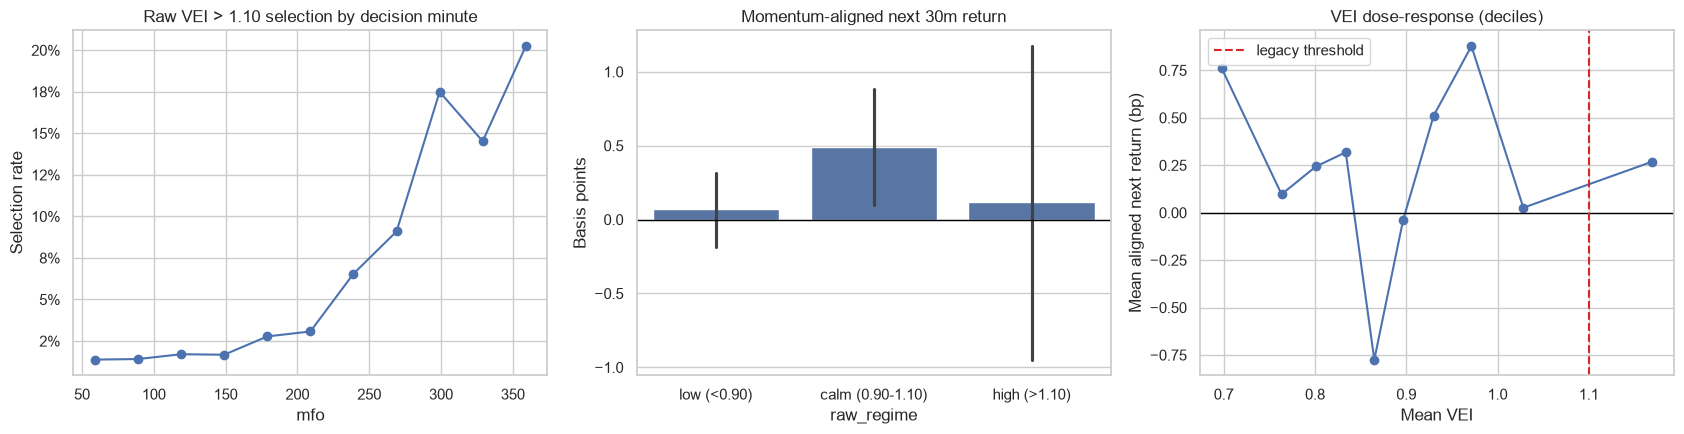

Interpretation: the conclusion is supported only if the high regime has stronger past-to-future alignment. A near-zero directional IC means VEI itself does not say up or down.


In [9]:
slot_selection = repro.assign(high=repro.vei_raw > 1.10).groupby('mfo')['high'].mean()
repro['vei_bin'] = pd.qcut(repro['vei_raw'], 10, labels=False, duplicates='drop')
dose = repro.groupby('vei_bin').agg(vei_mean=('vei_raw','mean'), n=('vei_raw','size'), aligned_bp=('aligned_fwd_bp','mean'))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
slot_selection.plot(marker='o', ax=axes[0], title='Raw VEI > 1.10 selection by decision minute')
axes[0].set_ylabel('Selection rate'); axes[0].yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
sns.barplot(data=repro, x='raw_regime', y='aligned_fwd_bp', errorbar=('ci', 90), ax=axes[1])
axes[1].axhline(0, color='black', lw=1); axes[1].set_title('Momentum-aligned next 30m return')
axes[1].set_ylabel('Basis points')
axes[2].plot(dose.vei_mean, dose.aligned_bp, marker='o')
axes[2].axhline(0, color='black', lw=1); axes[2].axvline(1.10, color='tab:red', ls='--', label='legacy threshold')
axes[2].set(title='VEI dose-response (deciles)', xlabel='Mean VEI', ylabel='Mean aligned next return (bp)'); axes[2].legend()
plt.tight_layout(); plt.show()

print('Interpretation: the conclusion is supported only if the high regime has stronger past-to-future alignment. A near-zero directional IC means VEI itself does not say up or down.')


## 5. Statistics, IC, dose-response, and graphs for every feature

Information coefficient (IC) is Spearman rank correlation. `signed_return_ic` measures direction; `absolute_return_ic` measures whether a feature predicts the size of the move. P-values are descriptive only because intraday rows are dependent. Year-by-year IC and the strategy's daily statistics are more honest stability checks.


In [10]:
analysis_sample = d.loc[d.sdate <= EVAL_END].copy()
stats = analysis_sample[feature_columns_numeric].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T
stats['coverage'] = analysis_sample[feature_columns_numeric].notna().mean()
display(stats[['coverage','count','mean','std','1%','5%','25%','50%','75%','95%','99%']].style.format('{:.4g}'))

def corr_from_sufficient_sums(s):
    n, sx, sy, sxx, syy, sxy = s
    cov = sxy - sx * sy / n
    vx = sxx - sx * sx / n; vy = syy - sy * sy / n
    return cov / np.sqrt(vx * vy) if vx > 0 and vy > 0 else np.nan

def fixed_rank_session_block_ic(frame, xcol, ycol, draws, rng):
    z = frame[['sdate', xcol, ycol]].dropna().copy()
    if len(z) < 50 or z[xcol].nunique() < 3:
        return np.nan, np.nan, np.nan
    z['rx'] = z[xcol].rank(method='average')
    z['ry'] = z[ycol].rank(method='average')
    z['rxx'] = z.rx * z.rx; z['ryy'] = z.ry * z.ry; z['rxy'] = z.rx * z.ry
    grouped = z.groupby('sdate', sort=False)
    per_session = np.column_stack([grouped.size().to_numpy(float),
                                   grouped.rx.sum().to_numpy(float), grouped.ry.sum().to_numpy(float),
                                   grouped.rxx.sum().to_numpy(float), grouped.ryy.sum().to_numpy(float),
                                   grouped.rxy.sum().to_numpy(float)])
    real = corr_from_sufficient_sums(per_session.sum(axis=0))
    boot = np.empty(draws)
    ns = len(per_session)
    for b in range(draws):
        counts = np.bincount(rng.integers(0, ns, size=ns), minlength=ns)
        boot[b] = corr_from_sufficient_sums((per_session * counts[:, None]).sum(axis=0))
    return real, *np.nanpercentile(boot, [5, 95])

ic_rows = []
ic_rng = np.random.default_rng(RANDOM_SEED)
for feature in feature_columns_numeric:
    g = analysis_sample[[feature,'target_ret_bp','abs_target_bp']].dropna()
    if len(g) < 50 or g[feature].nunique() < 3:
        continue
    signed = spearmanr(g[feature], g['target_ret_bp'])
    absolute = spearmanr(g[feature], g['abs_target_bp'])
    signed_ic, signed_lo, signed_hi = fixed_rank_session_block_ic(analysis_sample, feature, 'target_ret_bp', IC_BOOT_DRAWS, ic_rng)
    abs_ic, abs_lo, abs_hi = fixed_rank_session_block_ic(analysis_sample, feature, 'abs_target_bp', IC_BOOT_DRAWS, ic_rng)
    ic_rows.append({'feature':feature, 'n':len(g), 'signed_return_ic':signed_ic, 'signed_ci_lo':signed_lo, 'signed_ci_hi':signed_hi,
                    'absolute_return_ic':abs_ic, 'absolute_ci_lo':abs_lo, 'absolute_ci_hi':abs_hi,
                    'signed_naive_p':signed.pvalue, 'absolute_naive_p':absolute.pvalue})
ic_table = pd.DataFrame(ic_rows).set_index('feature').sort_values('signed_return_ic')
display(ic_table.style.format({'signed_return_ic':'{:+.4f}','signed_ci_lo':'{:+.4f}','signed_ci_hi':'{:+.4f}',
                               'absolute_return_ic':'{:+.4f}','absolute_ci_lo':'{:+.4f}','absolute_ci_hi':'{:+.4f}',
                               'signed_naive_p':'{:.3g}','absolute_naive_p':'{:.3g}'}))
print('Confidence intervals are 90% fixed-rank session-block bootstrap intervals; naive p-values are shown only as a warning against row-independence inference.')


,coverage,count,mean,std,1%,5%,25%,50%,75%,95%,99%
vei_raw,0.9045,3.132e+04,0.8852,0.1336,0.6465,0.7034,0.7949,0.8697,0.9546,1.119,1.299
vei_smooth_3,0.9045,3.132e+04,0.8859,0.131,0.6496,0.7071,0.7978,0.8709,0.954,1.116,1.299
vei_pct,0.8872,3.072e+04,0.497,0.2937,0,0.04444,0.2444,0.5,0.7556,0.9556,1
vei_z_90,0.8872,3.072e+04,-0.002954,1.047,-1.971,-1.439,-0.6765,-0.1265,0.5225,1.796,3.256
dist_vwap_atr14,0.9963,3.45e+04,1.278,6.367,-12.65,-8.476,-2.752,0.7752,4.768,12.81,18.91
rsi_14,0.9963,3.45e+04,50.81,11.38,24.07,31.6,43.07,51.14,58.72,69.03,75.54
time_fraction,1,3.463e+04,0.456,0.2429,0.07436,0.07436,0.2282,0.459,0.6897,0.8436,0.8436
time_sin,1,3.463e+04,0.05463,0.7519,-0.9945,-0.9945,-0.832,0.2549,0.8137,0.9906,0.9906
time_cos,1,3.463e+04,-0.1708,0.6344,-0.9747,-0.9747,-0.7591,-0.3395,0.5547,0.8928,0.8928
dow_sin,1,3.463e+04,0.005386,0.7089,-0.9511,-0.9511,-0.5878,0,0.5878,0.9511,0.9511


,n,signed_return_ic,signed_ci_lo,signed_ci_hi,absolute_return_ic,absolute_ci_lo,absolute_ci_hi,signed_naive_p,absolute_naive_p
feature,,,,,,,,,
close_vs_prior_low_15m_atr,34360,-0.0078,-0.0167,+0.0013,-0.0511,-0.0607,-0.0421,0.146,2.66e-21
ret_1m,34419,-0.0069,-0.0164,+0.0043,-0.0146,-0.0236,-0.0049,0.203,0.00691
donchian_pos_15m,34407,-0.0068,-0.0160,+0.0008,-0.0504,-0.0597,-0.0426,0.206,8.45e-21
close_location_value,34406,-0.0068,-0.0154,+0.0012,-0.0153,-0.0237,-0.0066,0.21,0.0045
ret_5m,34415,-0.0067,-0.0165,+0.0028,-0.0241,-0.0327,-0.0141,0.211,7.99e-06
time_fraction,34419,-0.0066,-0.0157,+0.0023,-0.1270,-0.1345,-0.1188,0.218,1.11e-123
close_vs_prior_high_15m_atr,34360,-0.0045,-0.0129,+0.0041,-0.0481,-0.0572,-0.0390,0.405,4.91e-19
close_vs_prior_low_60m_atr,28020,-0.0031,-0.0123,+0.0074,-0.1042,-0.1139,-0.0947,0.599,1.9e-68
rsi_14,34360,-0.0024,-0.0117,+0.0053,-0.0801,-0.0894,-0.0717,0.659,4.98e-50


Confidence intervals are 90% fixed-rank session-block bootstrap intervals; naive p-values are shown only as a warning against row-independence inference.


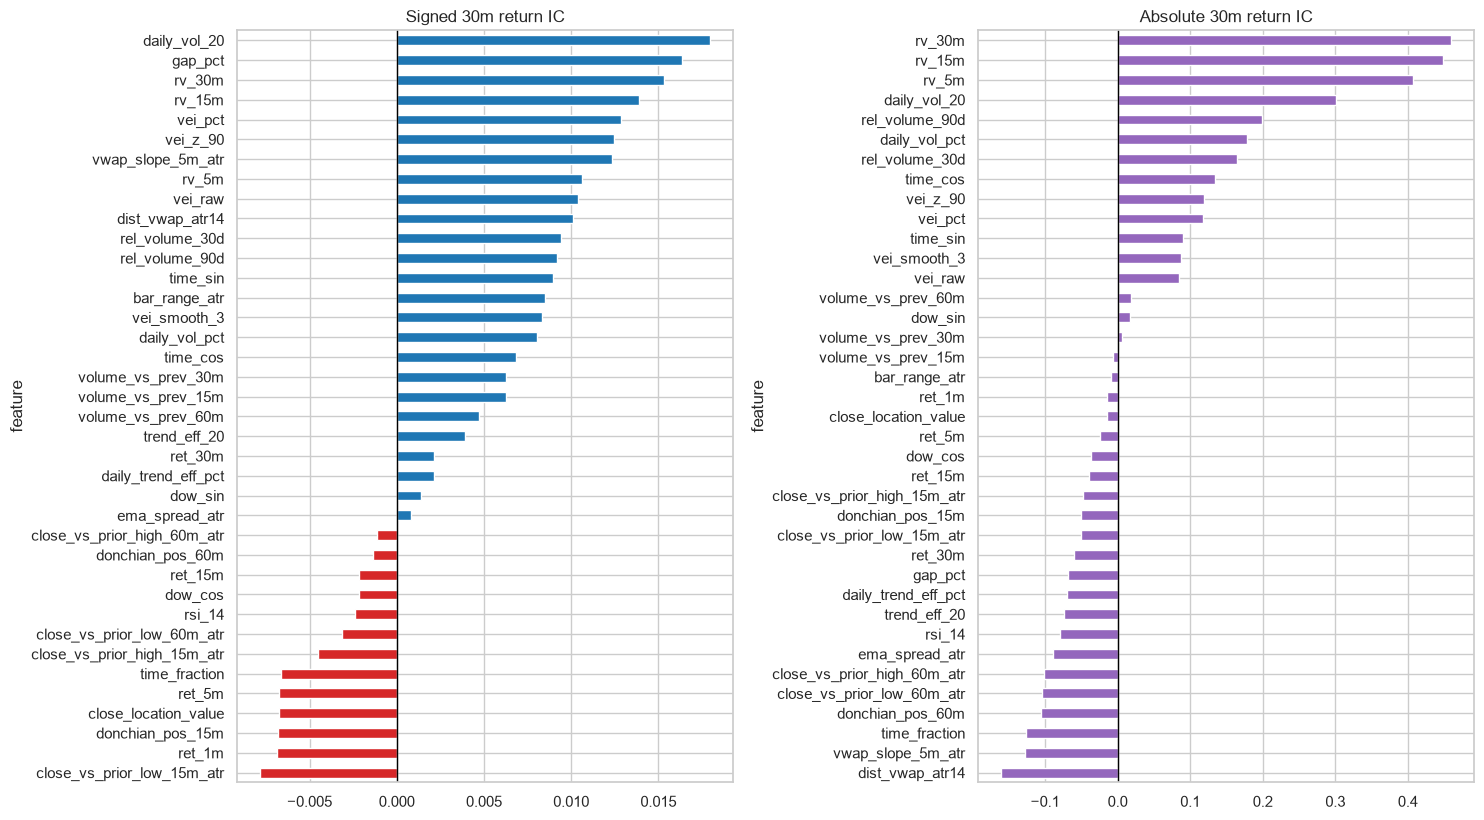

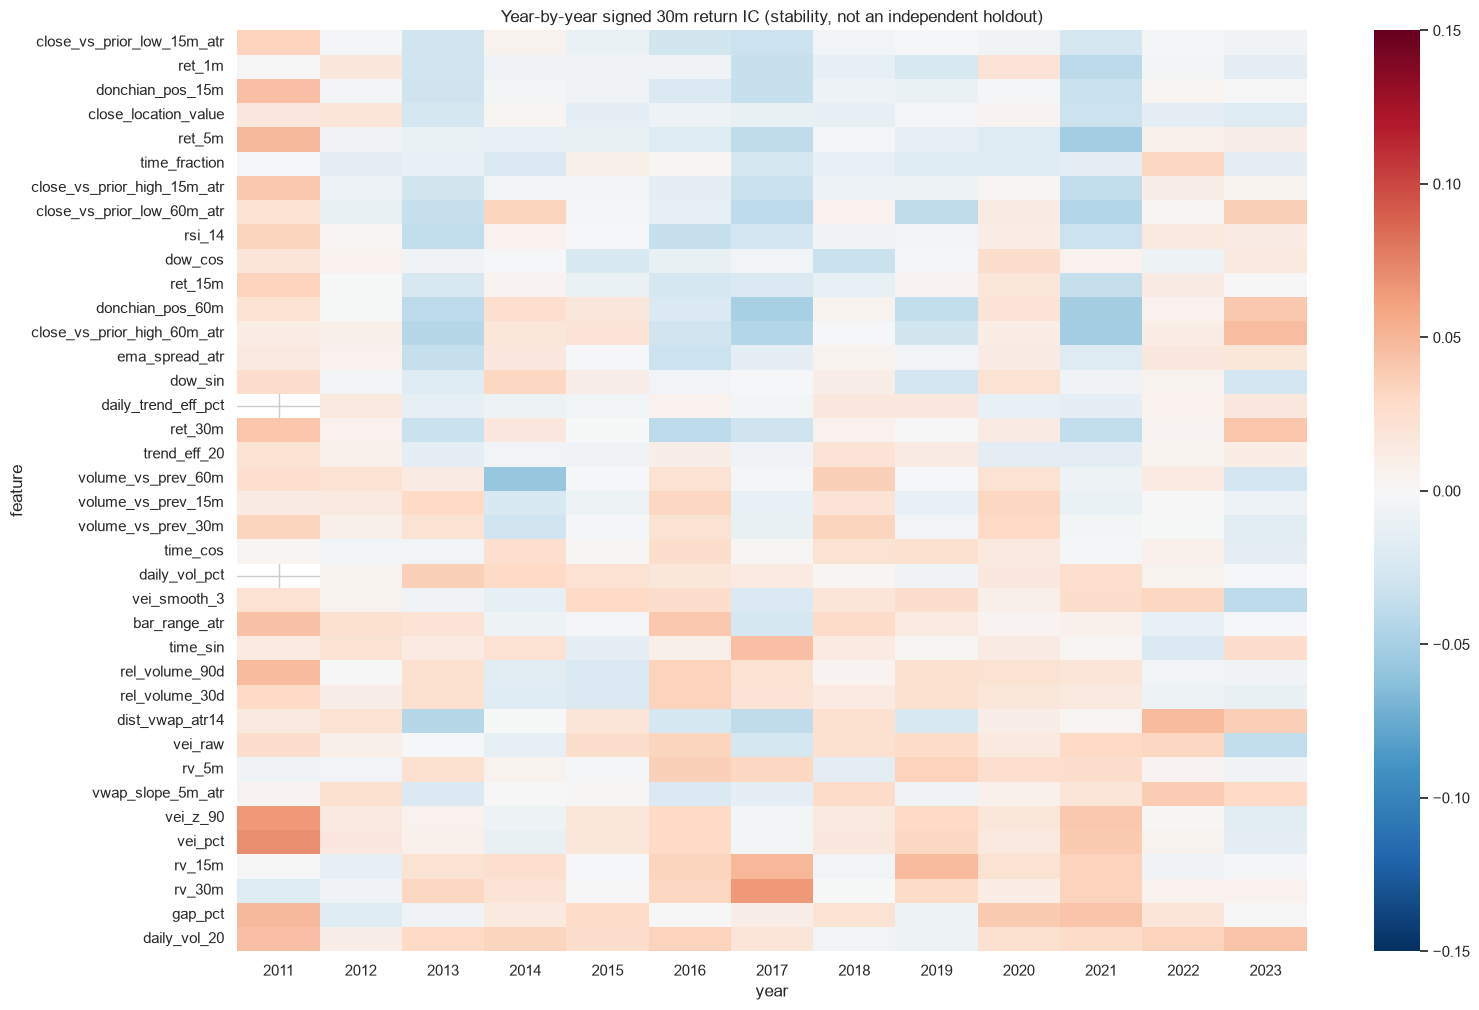

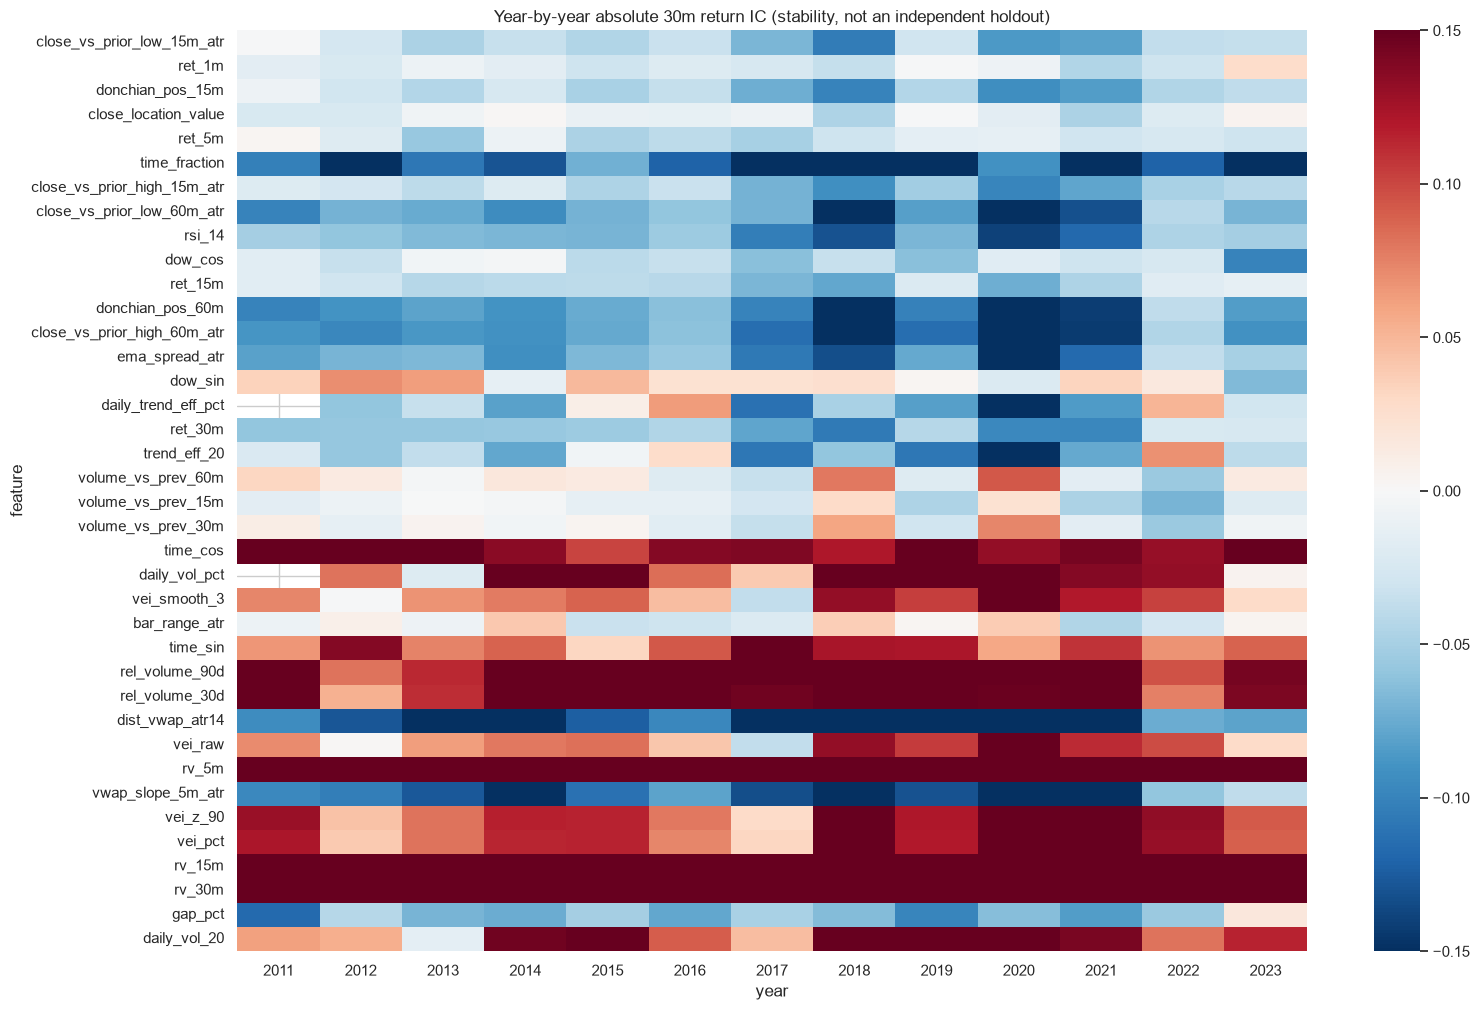

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, max(7, len(ic_table) * .22)))
ic_table['signed_return_ic'].plot.barh(ax=axes[0], color=np.where(ic_table.signed_return_ic >= 0, 'tab:blue', 'tab:red'))
axes[0].axvline(0, color='black', lw=1); axes[0].set_title('Signed 30m return IC')
ic_table.sort_values('absolute_return_ic')['absolute_return_ic'].plot.barh(ax=axes[1], color='tab:purple')
axes[1].axvline(0, color='black', lw=1); axes[1].set_title('Absolute 30m return IC')
plt.tight_layout(); plt.show()

year_ic_rows = []
for feature in feature_columns_numeric:
    for year, g in analysis_sample.groupby(analysis_sample.sdate.dt.year):
        z = g[[feature,'target_ret_bp','abs_target_bp']].dropna()
        if len(z) >= 50 and z[feature].nunique() >= 3:
            year_ic_rows.append({'feature':feature,'year':year,
                                 'signed_ic':spearmanr(z[feature], z.target_ret_bp).statistic,
                                 'absolute_ic':spearmanr(z[feature], z.abs_target_bp).statistic})
year_ic = pd.DataFrame(year_ic_rows)
for metric, title in [('signed_ic','Signed'), ('absolute_ic','Absolute')]:
    year_ic_pivot = year_ic.pivot(index='feature', columns='year', values=metric).reindex(ic_table.index)
    plt.figure(figsize=(16, max(8, len(year_ic_pivot) * .27)))
    sns.heatmap(year_ic_pivot, center=0, cmap='RdBu_r', vmin=-.15, vmax=.15)
    plt.title(f'Year-by-year {title.lower()} 30m return IC (stability, not an independent holdout)')
    plt.tight_layout(); plt.show()


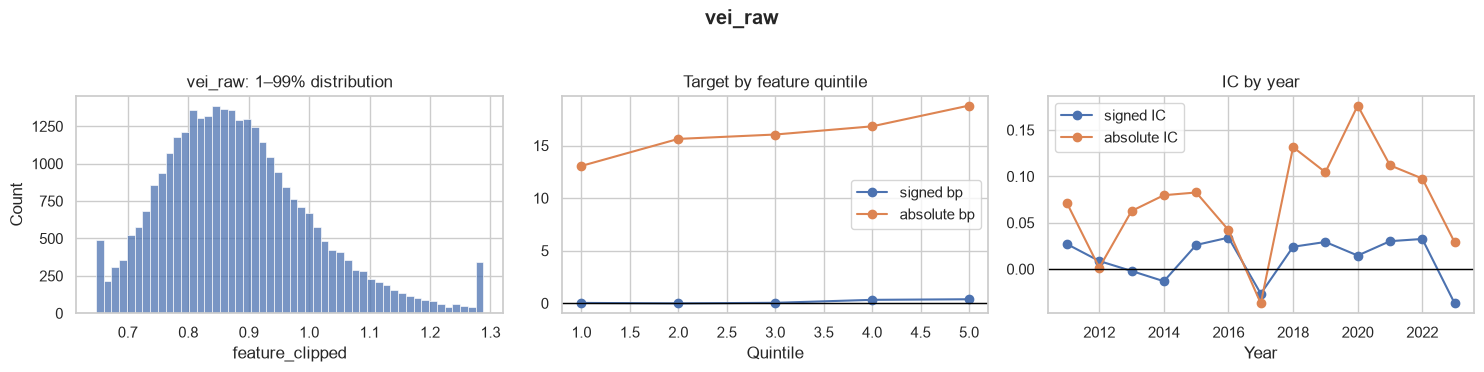

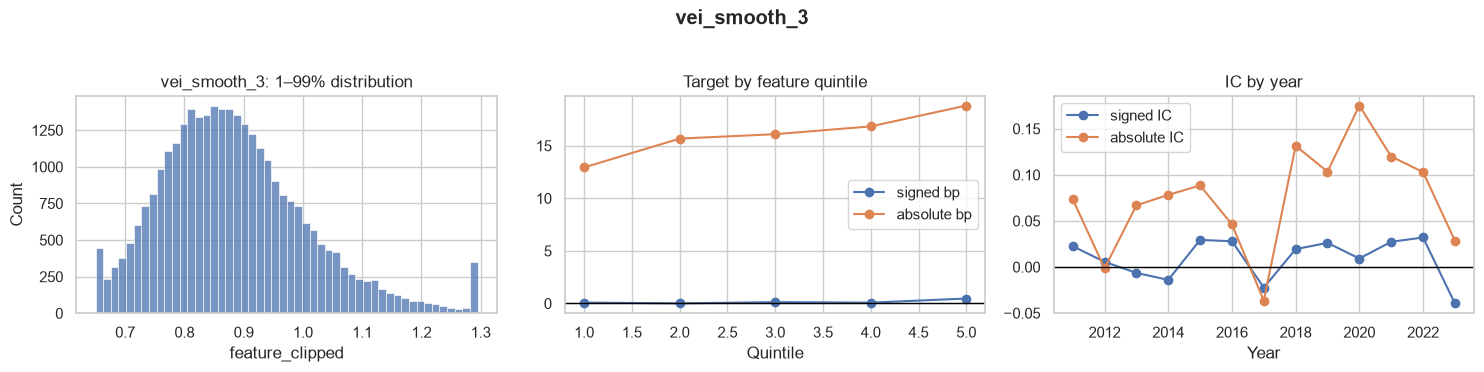

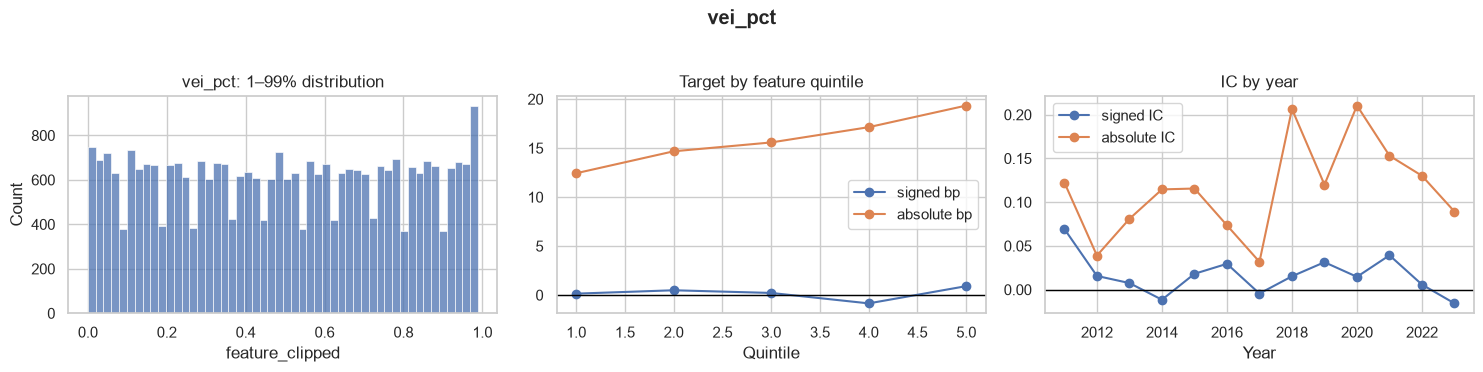

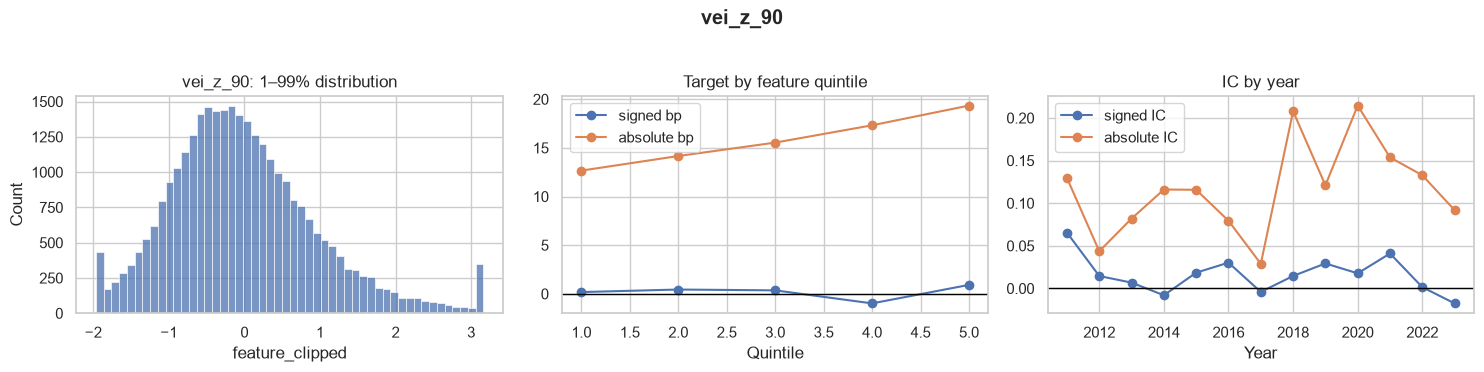

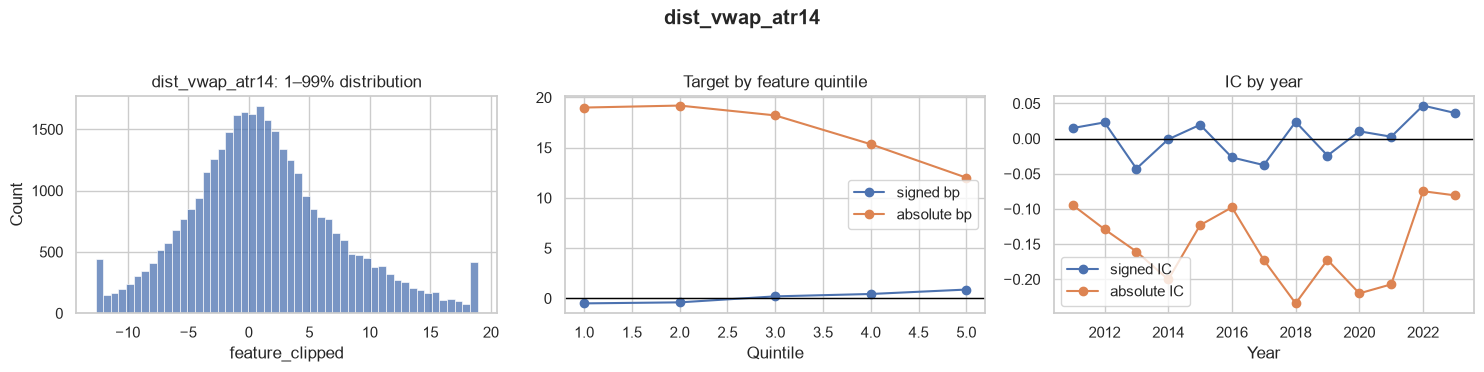

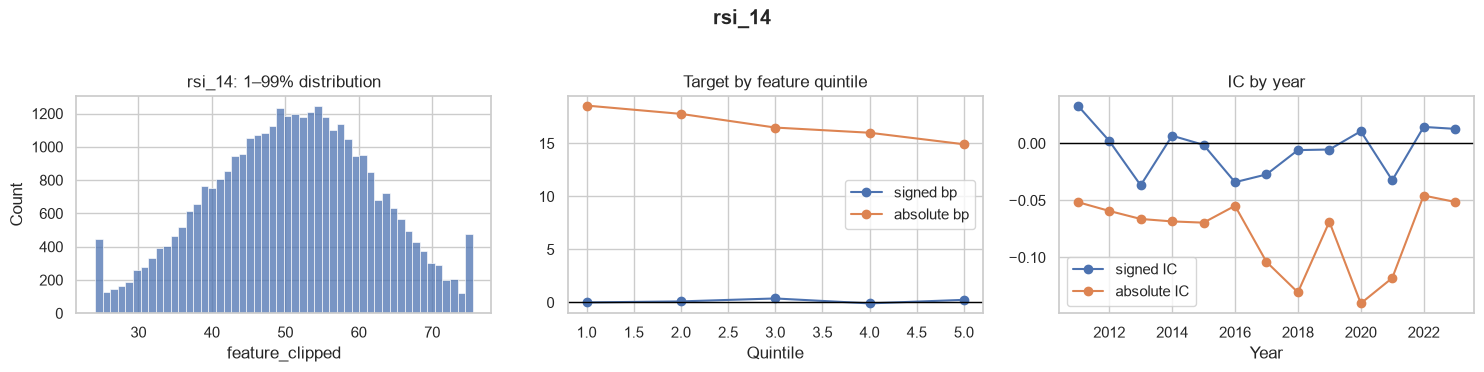

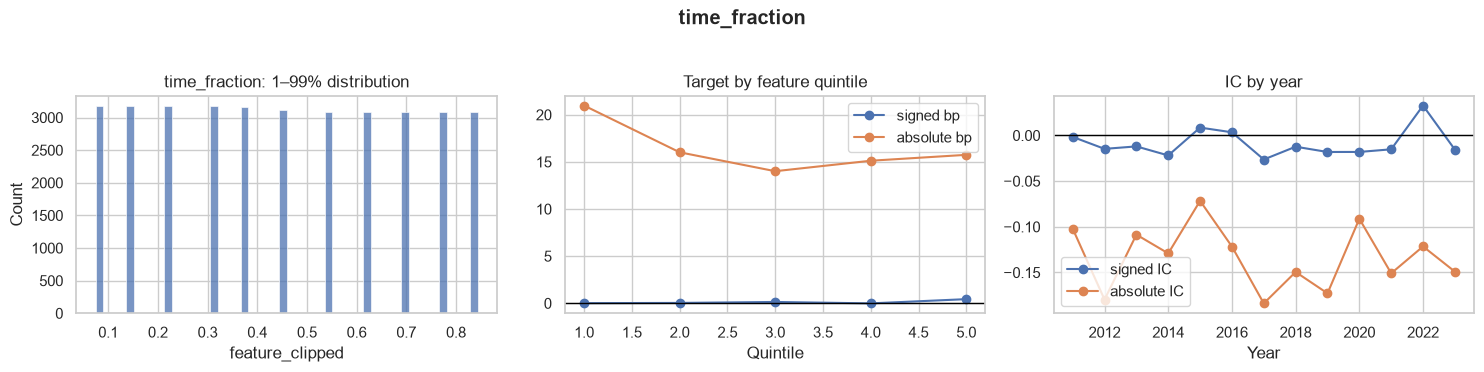

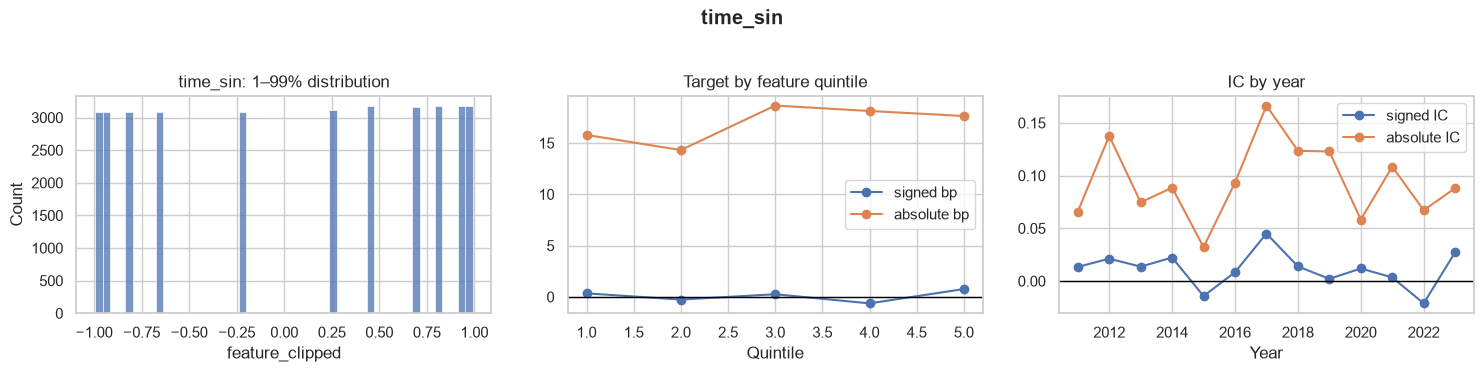

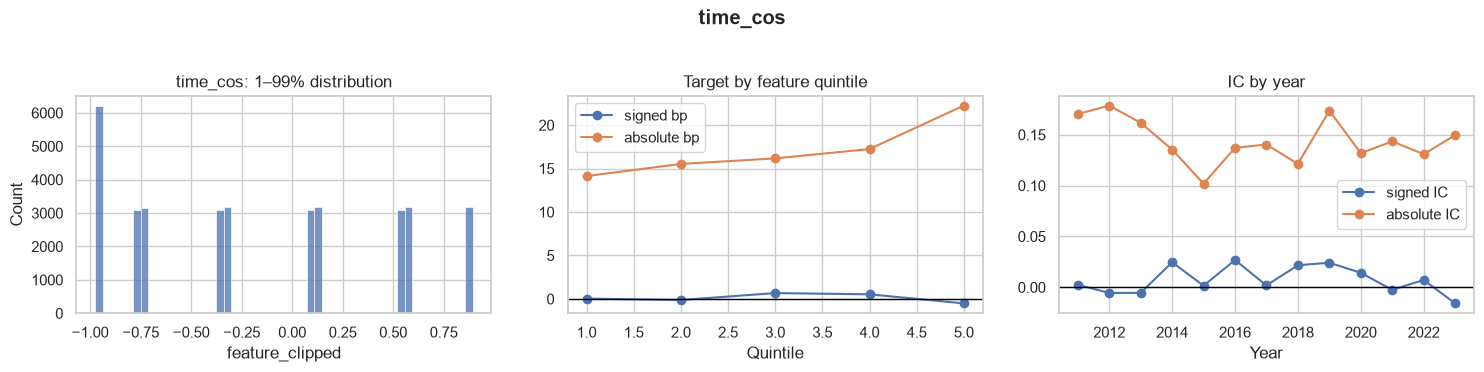

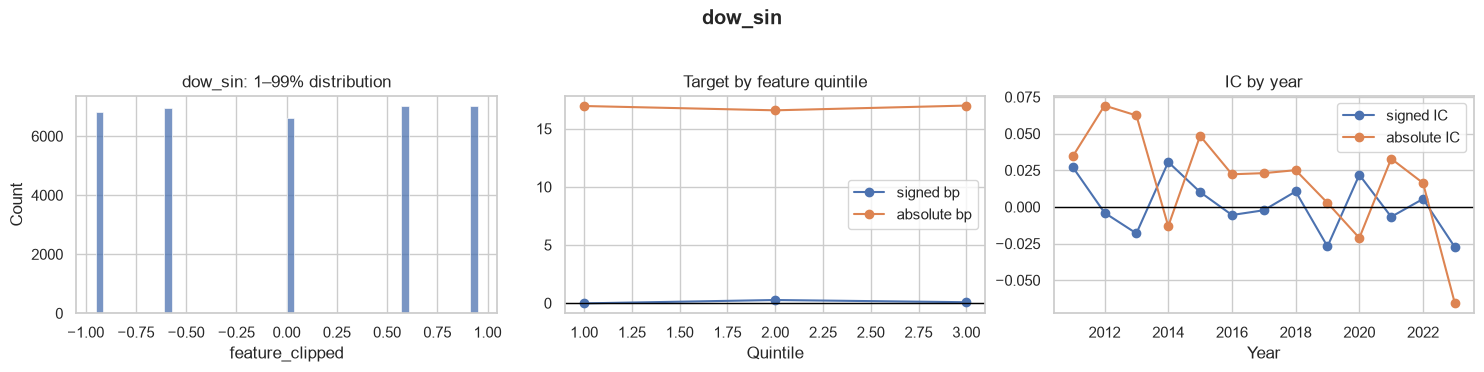

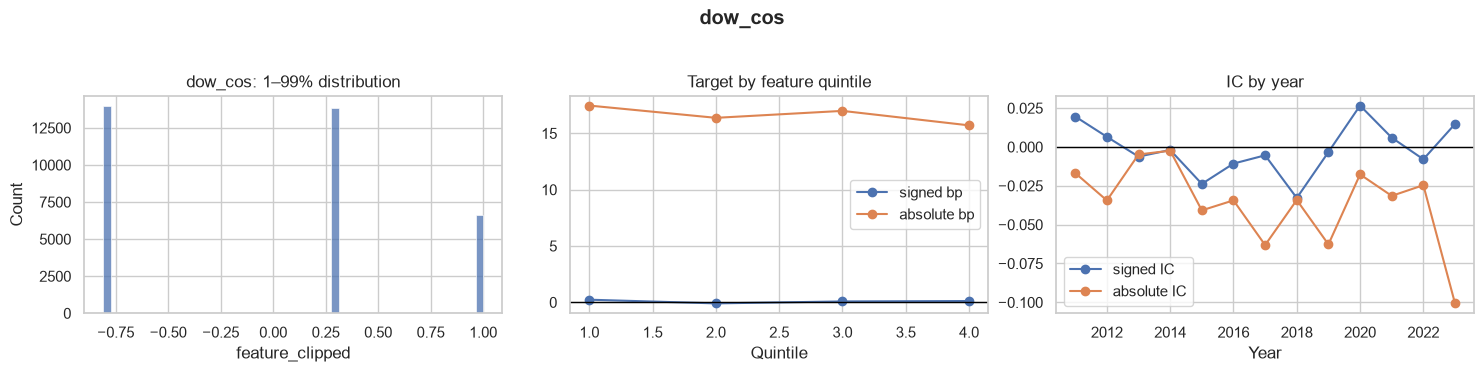

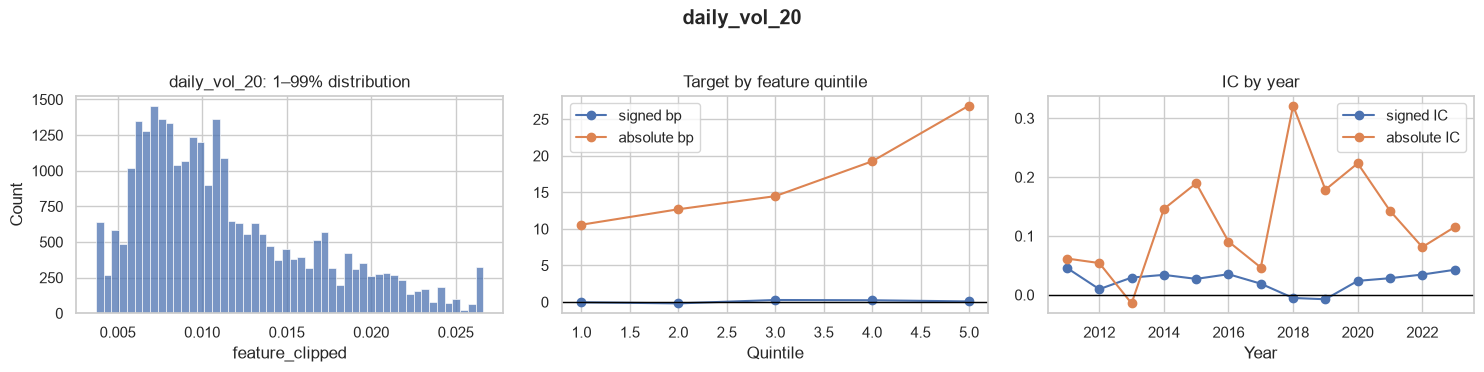

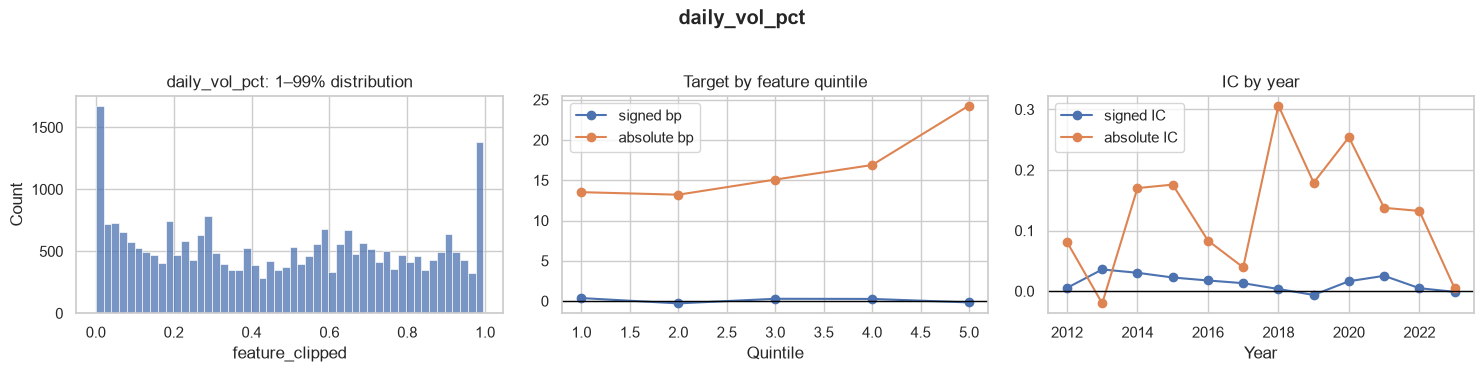

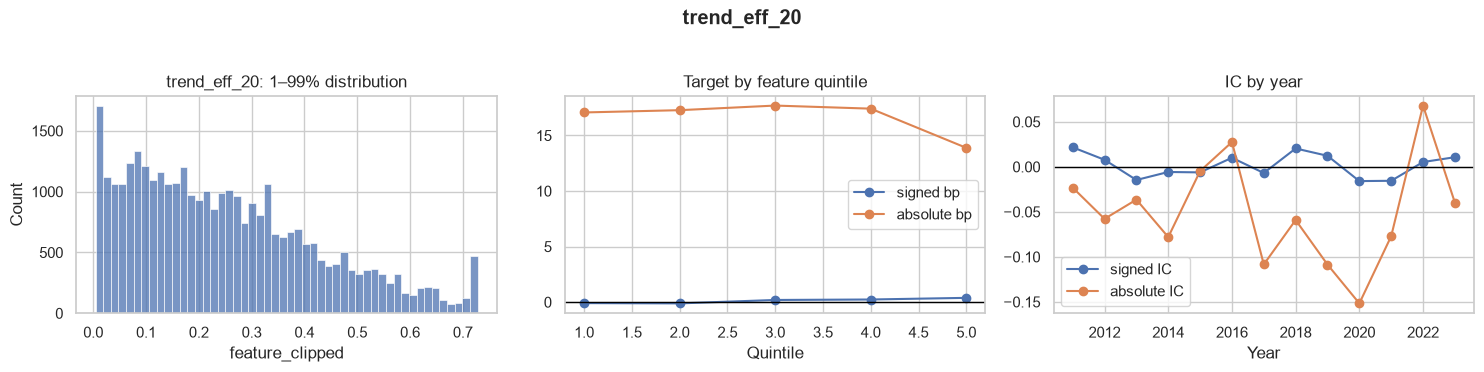

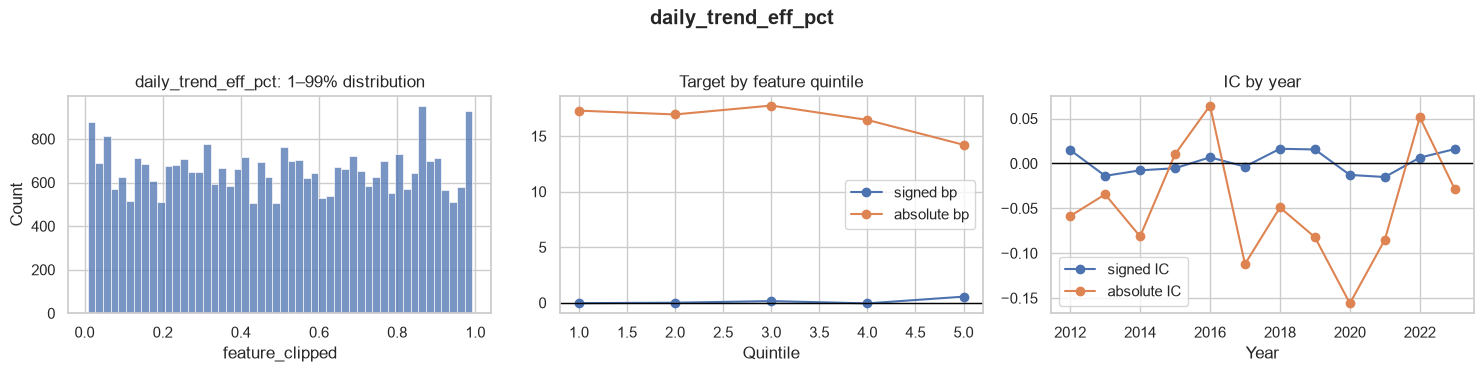

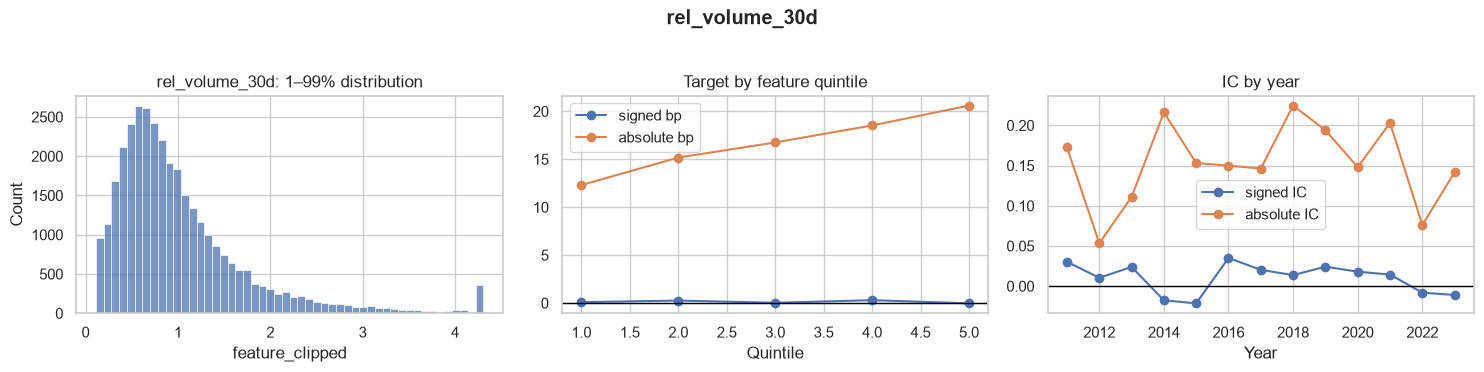

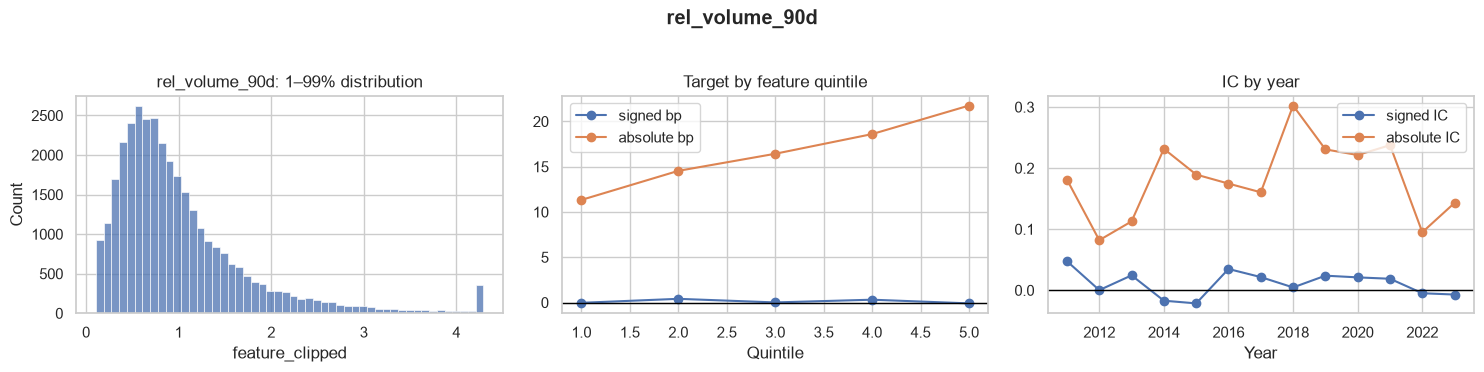

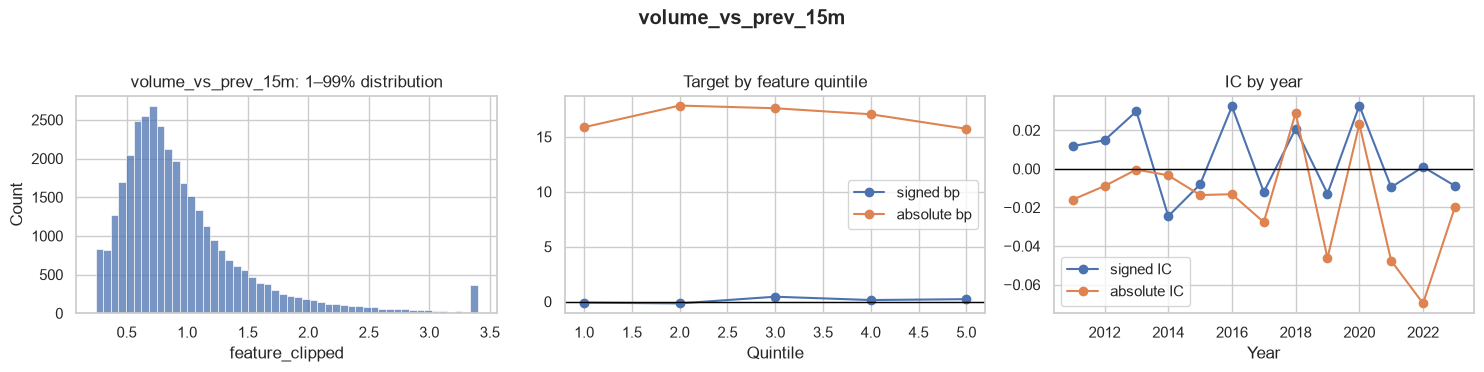

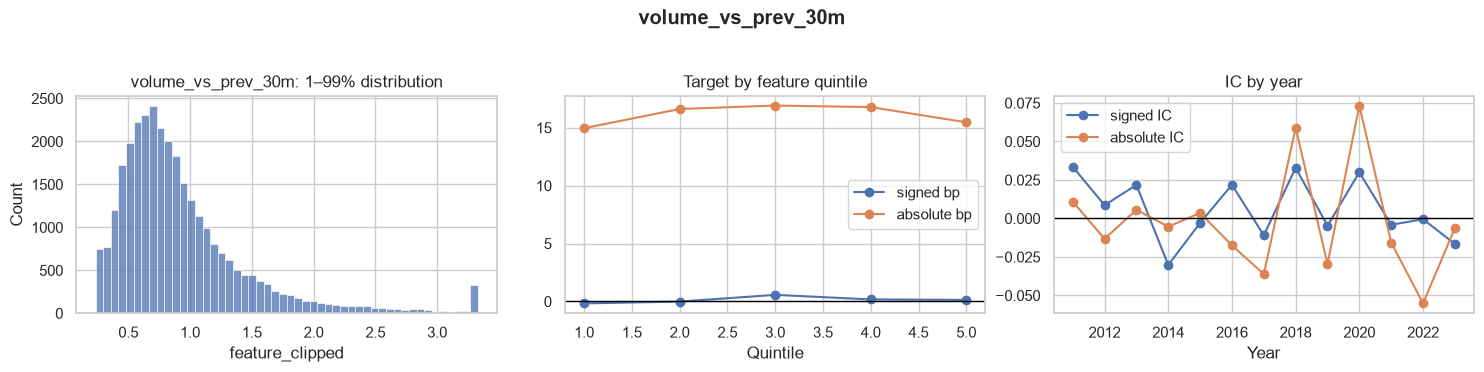

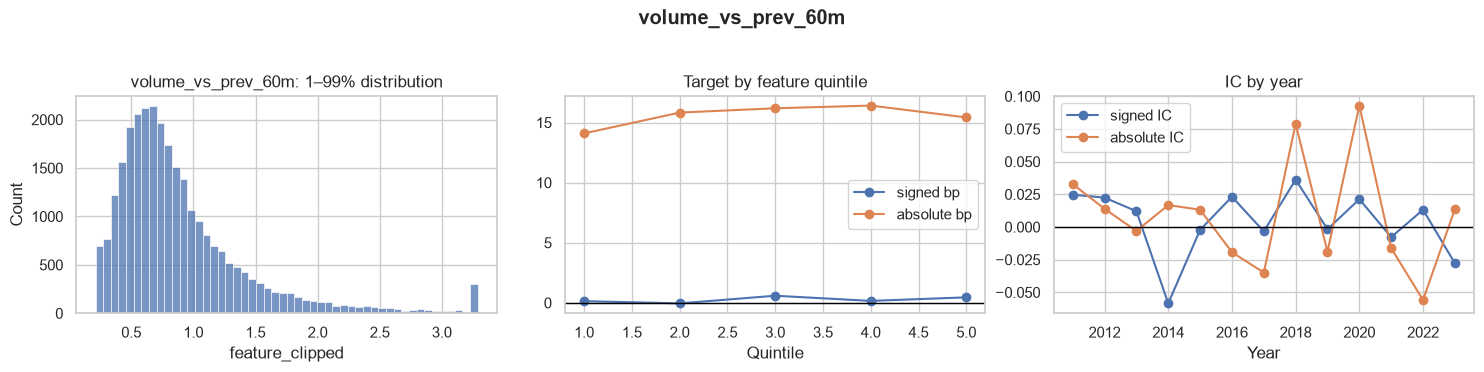

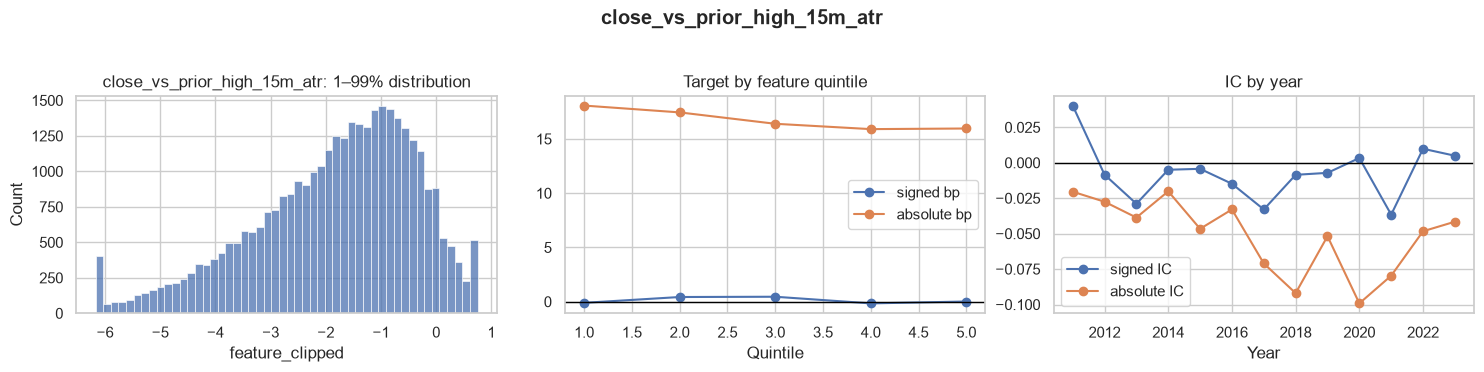

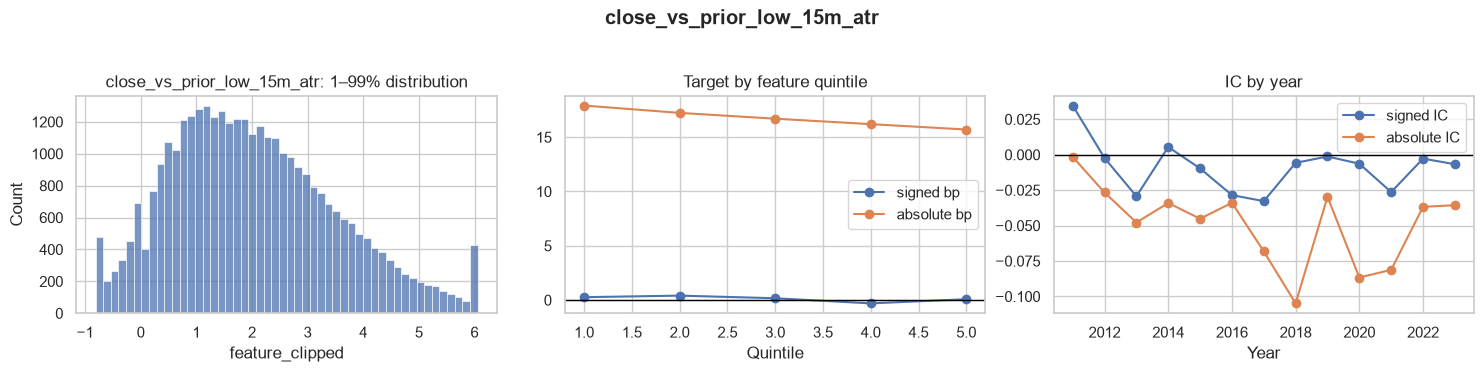

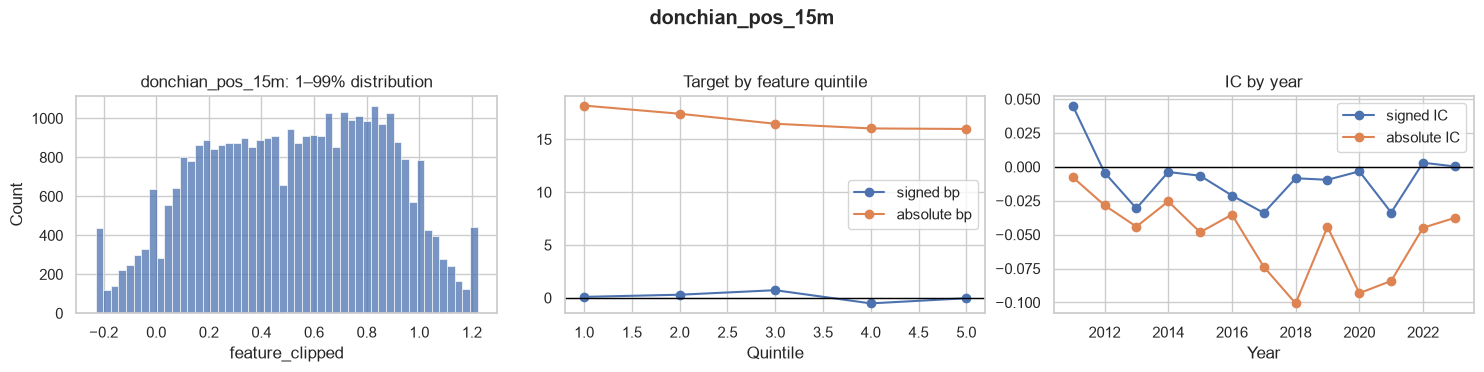

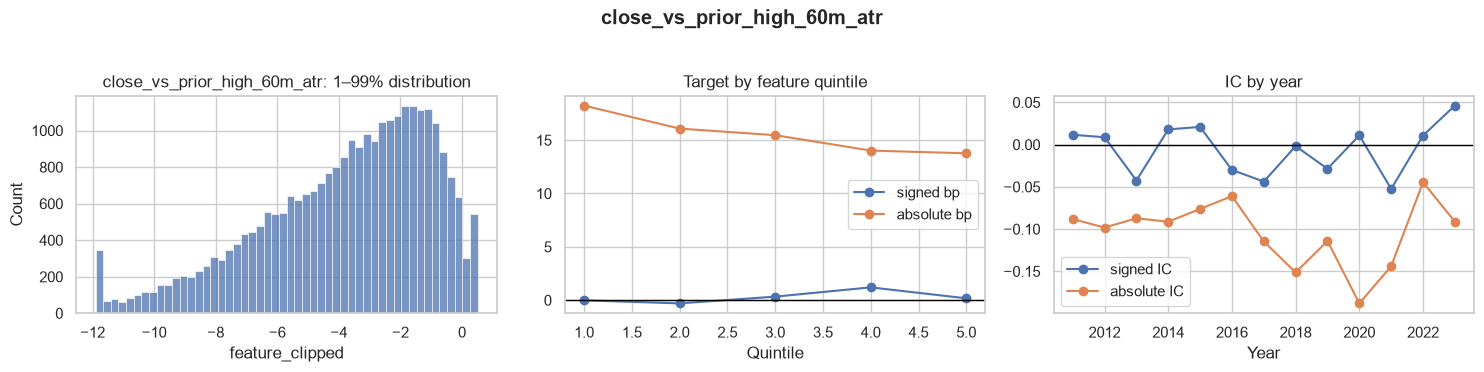

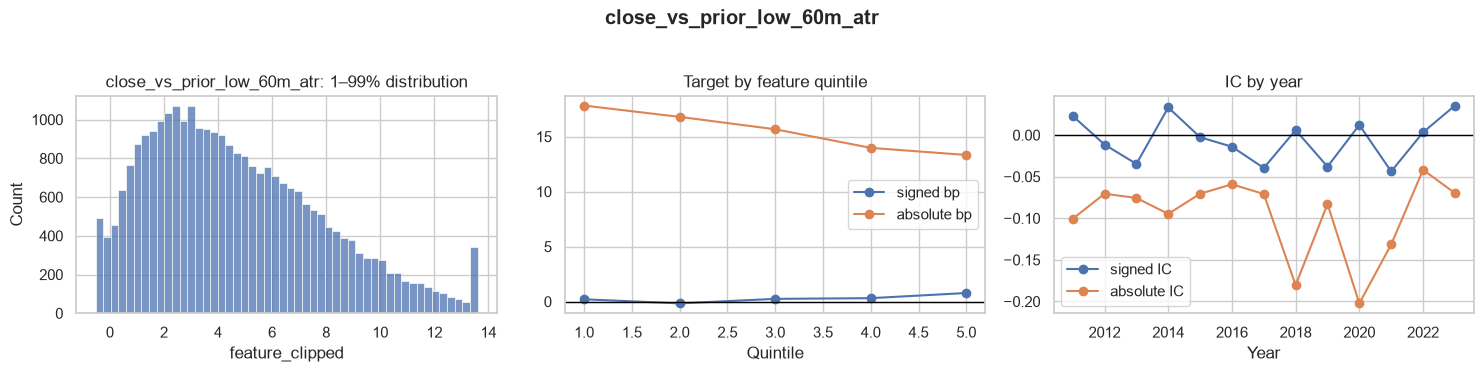

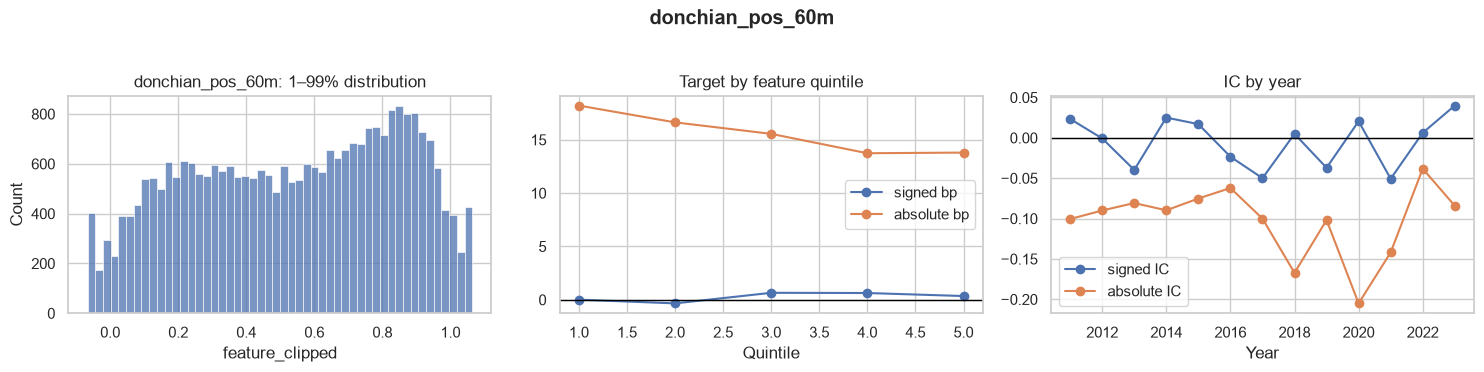

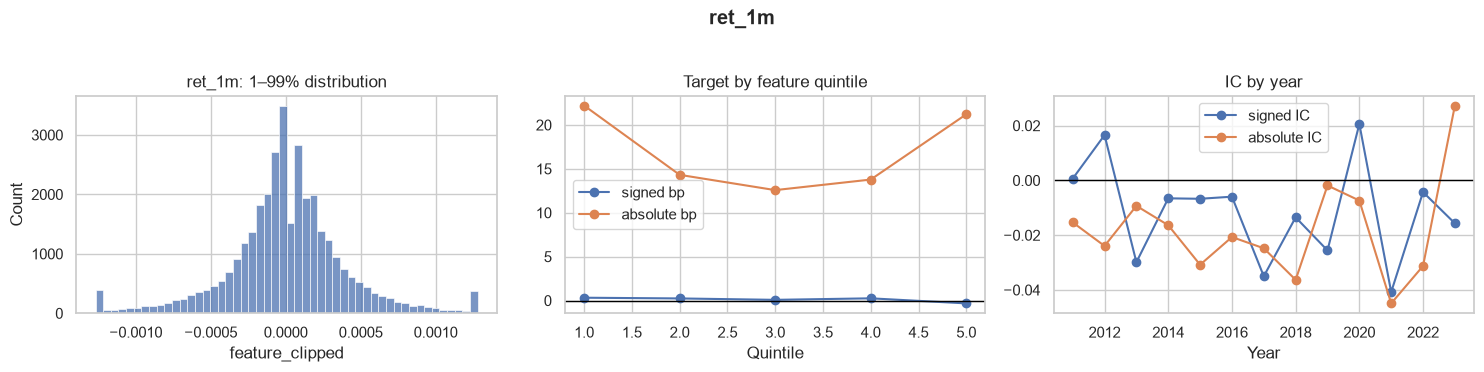

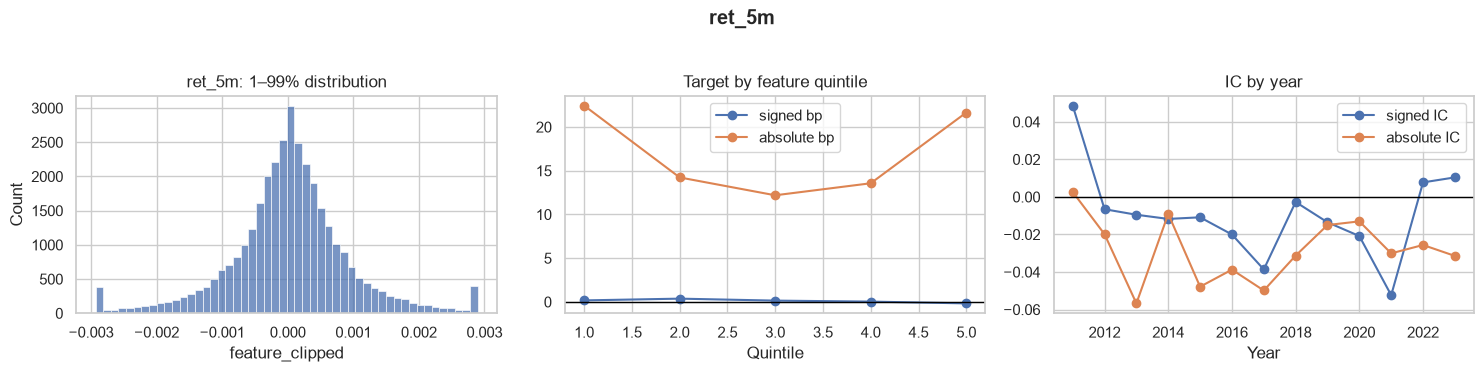

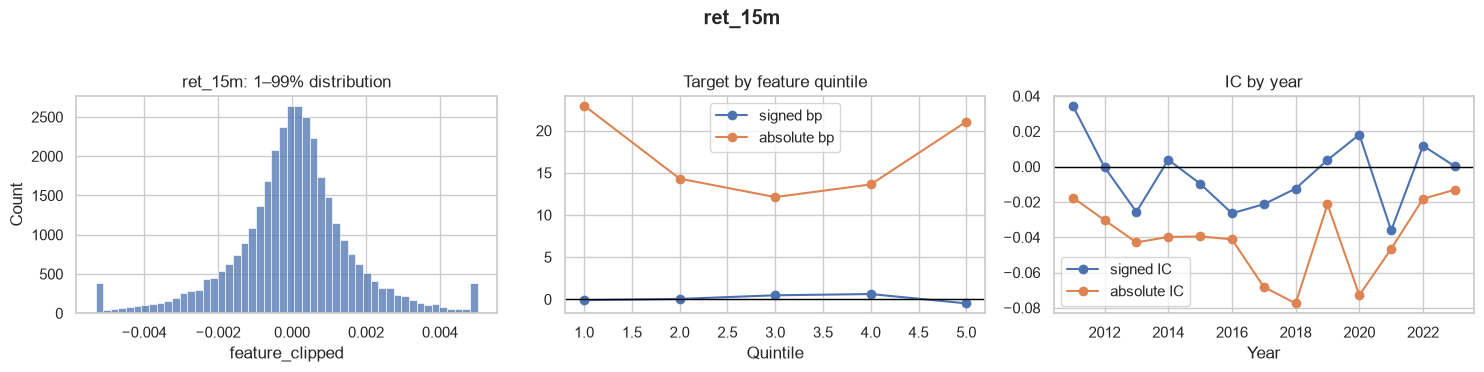

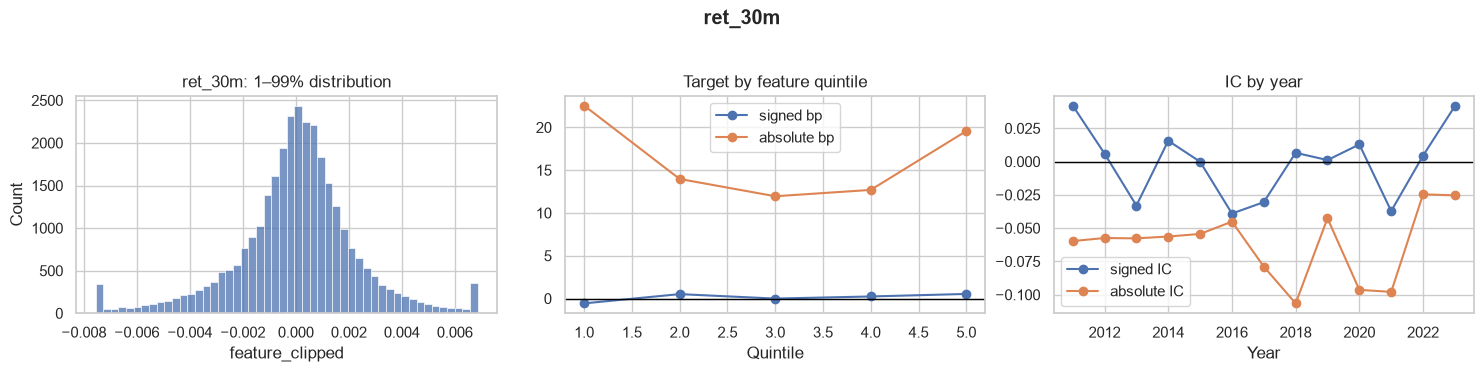

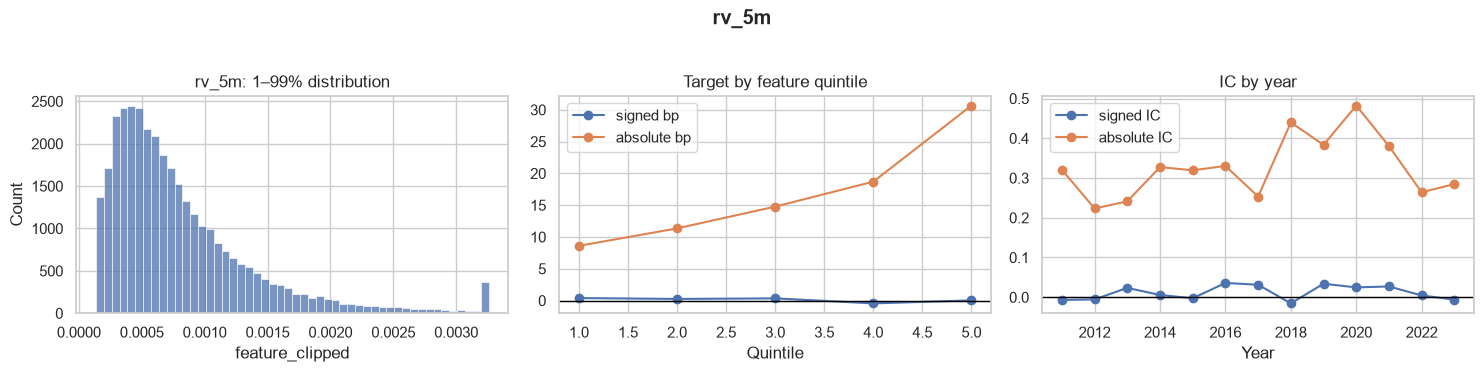

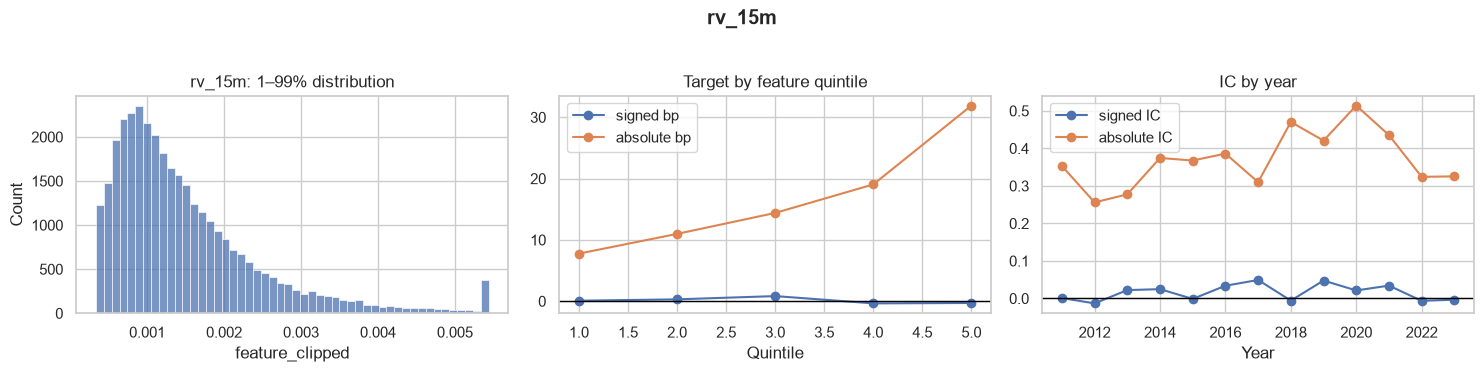

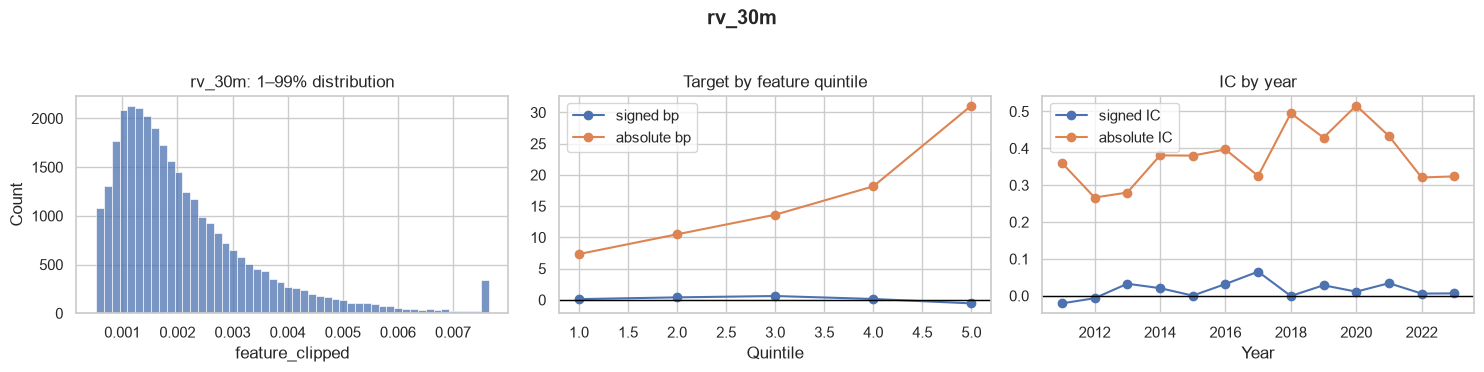

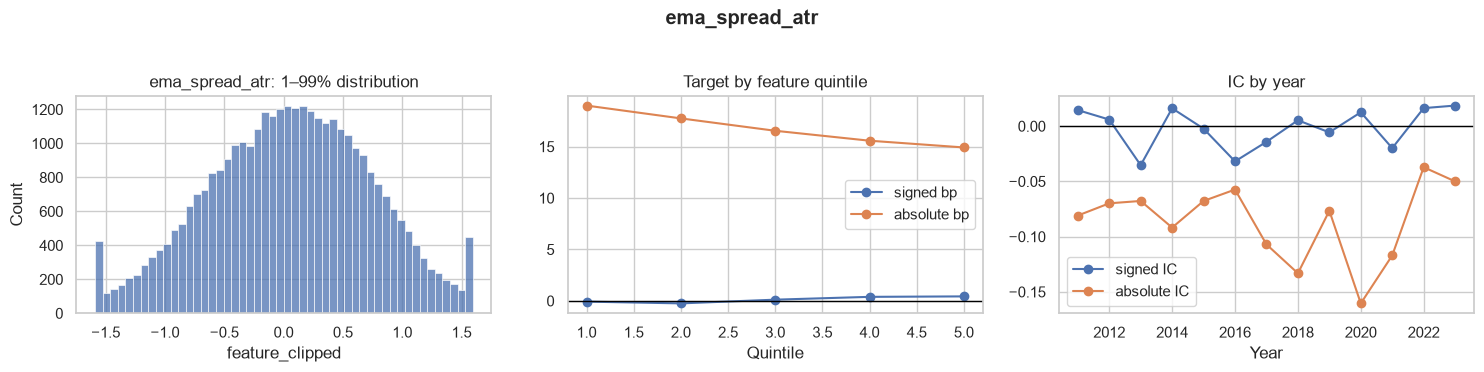

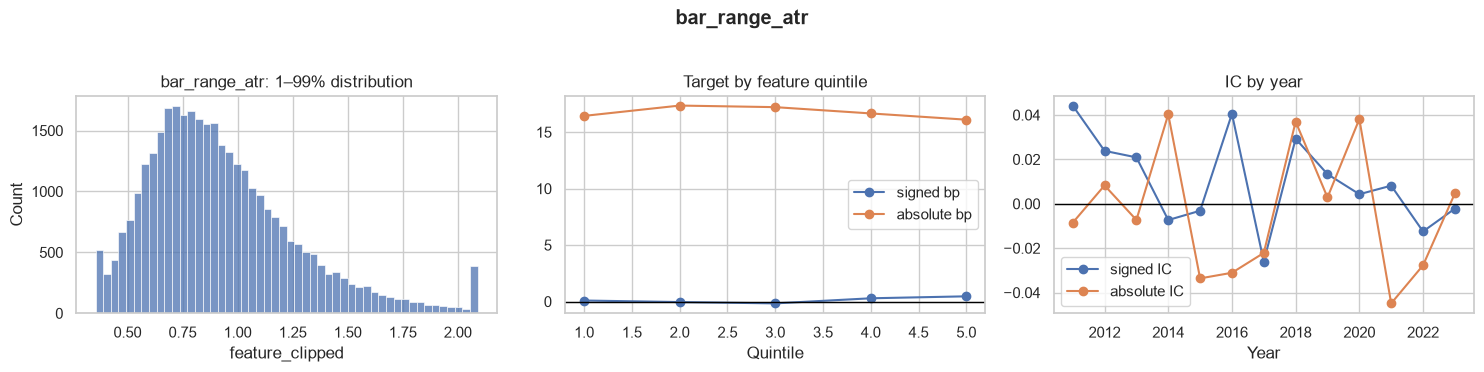

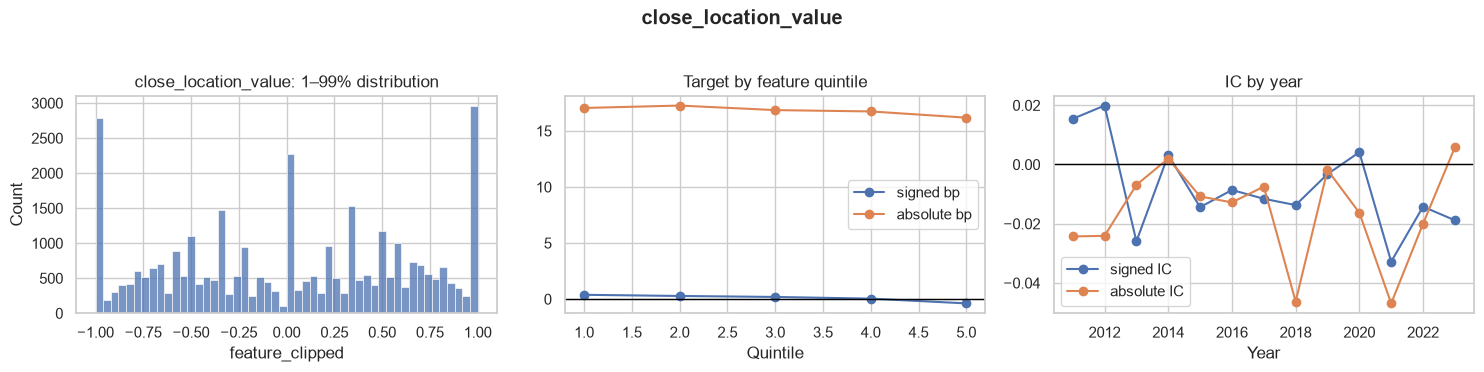

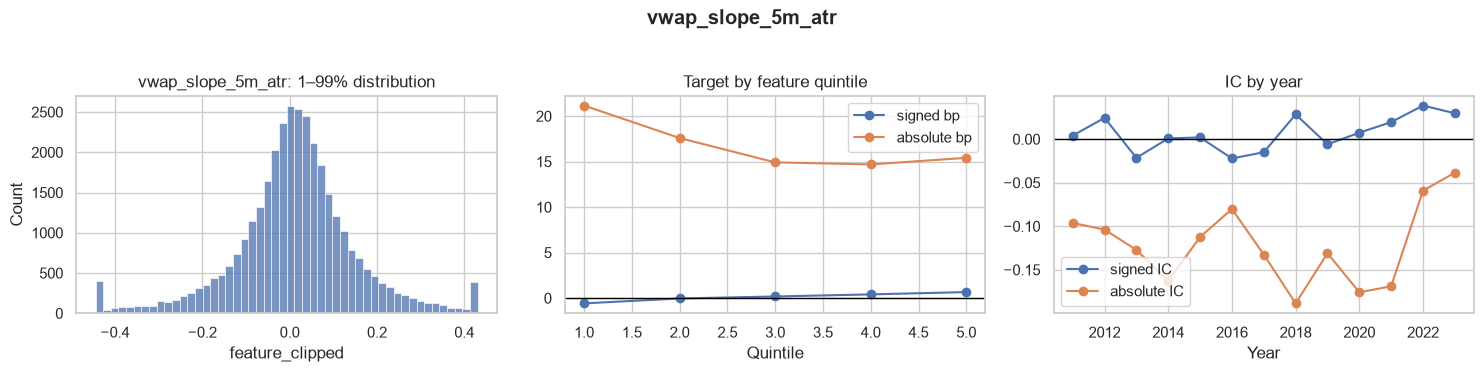

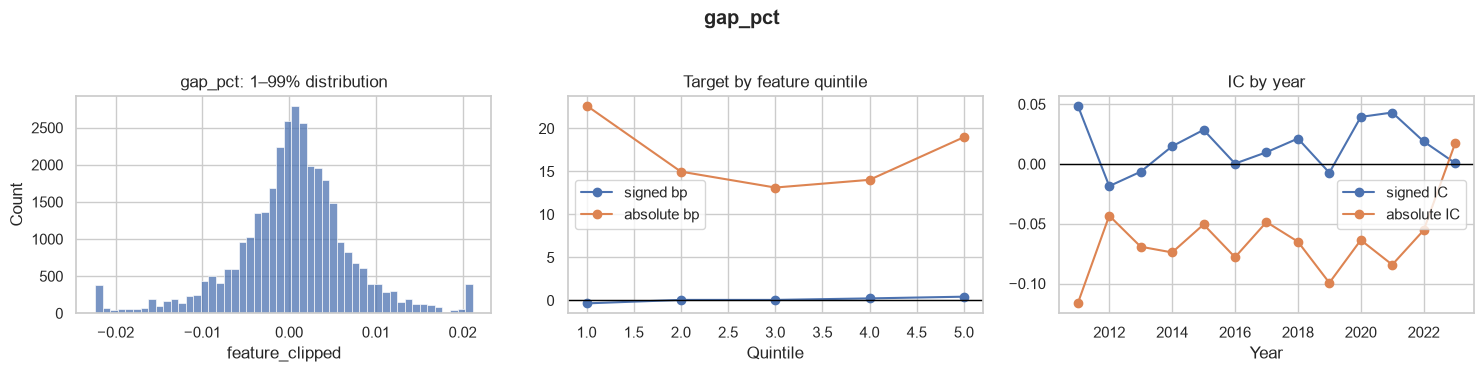

,n,mean_signed_bp,mean_abs_bp,up_rate
day_of_week,,,,
Fri,6856,-0.095,16.378,51.7%
Mon,6728,+0.115,15.709,52.1%
Thu,6988,+0.050,17.524,52.7%
Tue,7028,+0.078,16.994,52.1%
Wed,7027,+0.412,17.409,51.5%


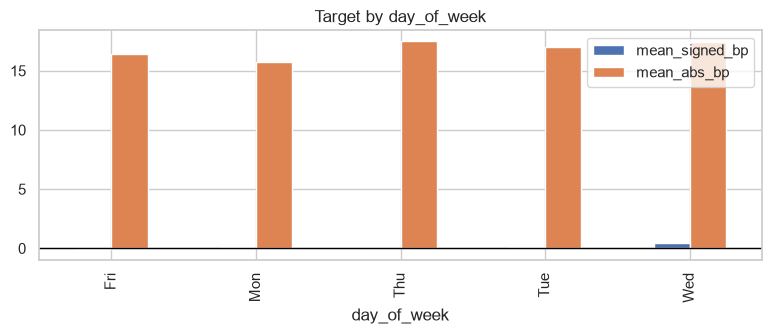

,n,mean_signed_bp,mean_abs_bp,up_rate
daily_vol_regime,,,,
low,10750,+0.044,13.355,52.1%
normal,7592,+0.381,15.289,52.8%
high,8555,-0.109,21.823,51.8%


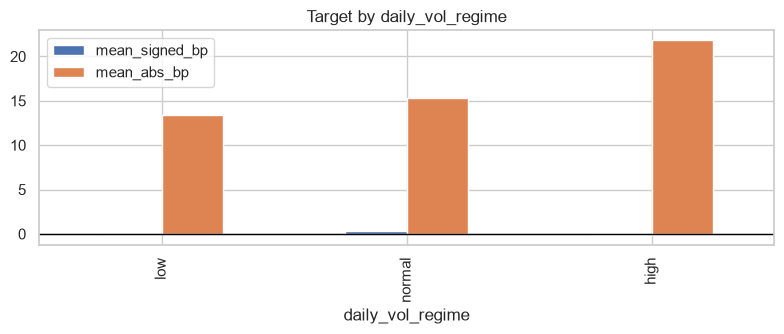

,n,mean_signed_bp,mean_abs_bp,up_rate
daily_market_regime,,,,
chop,11113,+0.135,17.270,51.9%
normal,10869,-0.098,17.297,51.6%
trend,11071,+0.319,15.056,52.8%


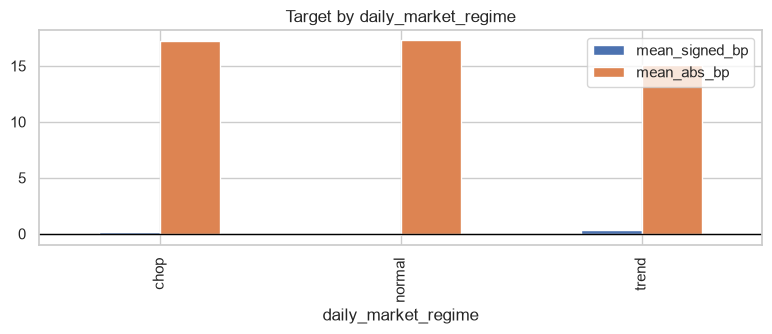

In [12]:
# One three-panel diagnostic per feature: clipped distribution, quintile response, yearly IC.
if PLOT_EACH_FEATURE:
    for feature in feature_columns_numeric:
        g = analysis_sample[['sdate',feature,'target_ret_bp','abs_target_bp']].dropna().copy()
        if len(g) < 100 or g[feature].nunique() < 5:
            continue
        lo, hi = g[feature].quantile([.01,.99])
        g['feature_clipped'] = g[feature].clip(lo, hi)
        g['quintile'] = pd.qcut(g[feature], 5, labels=False, duplicates='drop')
        q = g.groupby('quintile').agg(feature_mean=(feature,'mean'), signed_bp=('target_ret_bp','mean'), abs_bp=('abs_target_bp','mean'))
        yi = year_ic.loc[year_ic.feature == feature]
        fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
        sns.histplot(g['feature_clipped'], bins=50, ax=ax[0]); ax[0].set_title(f'{feature}: 1–99% distribution')
        ax[1].plot(q.index + 1, q.signed_bp, marker='o', label='signed bp'); ax[1].plot(q.index + 1, q.abs_bp, marker='o', label='absolute bp')
        ax[1].axhline(0, color='black', lw=1); ax[1].set(title='Target by feature quintile', xlabel='Quintile'); ax[1].legend()
        ax[2].plot(yi.year, yi.signed_ic, marker='o', label='signed IC'); ax[2].plot(yi.year, yi.absolute_ic, marker='o', label='absolute IC')
        ax[2].axhline(0, color='black', lw=1); ax[2].set(title='IC by year', xlabel='Year'); ax[2].legend()
        fig.suptitle(feature, y=1.03, fontweight='bold'); plt.tight_layout(); plt.show()

for category in feature_columns_categorical:
    summary = analysis_sample.groupby(category, observed=True).agg(n=('target_ret_bp','size'), mean_signed_bp=('target_ret_bp','mean'),
                                                                     mean_abs_bp=('abs_target_bp','mean'), up_rate=('target_up','mean'))
    display(summary.style.format({'mean_signed_bp':'{:+.3f}','mean_abs_bp':'{:.3f}','up_rate':'{:.1%}'}))
    summary[['mean_signed_bp','mean_abs_bp']].plot.bar(title=f'Target by {category}', figsize=(8,3.5)); plt.axhline(0,color='black',lw=1); plt.tight_layout(); plt.show()


## 6. Fixed VWAP-side strategy: every 30 minutes, hold 30 minutes

At each decision close: buy if `close > session VWAP`, sell if `close < session VWAP`. Fill next open, exit 30 minutes later at the open. One contract, non-overlapping positions, explicit two-sided fees and slippage. Daily P&L is the sum of trades. No stops, targets, or intrabar path assumptions are involved.


In [13]:
trades = d.loc[d.target_ret_bp.notna() & d.vwap_side.notna() & d.vwap_side.ne(0), [
    'sdate','mfo','era','vwap_side','entry_open','exit_open','daily_atr_14','vei_raw','vei_z_90','ret_30m','daily_vol_regime','daily_market_regime'
]].copy()
trades['side'] = trades['vwap_side'].astype(int)
trades['gross_points'] = trades['side'] * (trades['exit_open'] - trades['entry_open'])
trades['cost_points'] = ROUND_TRIP_COST_POINTS
trades['net_points'] = trades['gross_points'] - trades['cost_points']
trades['gross_dollars'] = trades['gross_points'] * POINT_VALUE
trades['net_dollars'] = trades['net_points'] * POINT_VALUE
trades['gross_r'] = trades['gross_points'] / trades['daily_atr_14']
trades['cost_r'] = trades['cost_points'] / trades['daily_atr_14']
trades['net_r'] = trades['gross_r'] - trades['cost_r']
trades['year'] = trades.sdate.dt.year

def strategy_statistics(frame, all_dates):
    day = frame.groupby('sdate')['net_points'].sum().reindex(pd.DatetimeIndex(all_dates), fill_value=0.0)
    day_dollars = day * POINT_VALUE
    valid_r = frame.loc[frame.daily_atr_14.notna() & frame.daily_atr_14.gt(0)]
    day_r = valid_r.groupby('sdate')['net_r'].sum().reindex(pd.DatetimeIndex(all_dates), fill_value=0.0)
    day_sd = day.std(ddof=1)
    equity = day.cumsum()
    dd = equity - equity.cummax()
    r_sd = day_r.std(ddof=1); r_equity = day_r.cumsum(); r_dd = r_equity - r_equity.cummax()
    gains = frame.loc[frame.net_points > 0, 'net_points'].sum()
    losses = -frame.loc[frame.net_points < 0, 'net_points'].sum()
    return pd.Series({
        'trades': len(frame), 'sessions': len(day), 'trades_per_session': len(frame) / max(len(day),1),
        'gross_points': frame.gross_points.sum(), 'net_points': frame.net_points.sum(),
        'net_dollars_1_contract': frame.net_dollars.sum(), 'mean_net_points_trade': frame.net_points.mean(),
        'median_net_points_trade': frame.net_points.median(), 'win_rate': (frame.net_points > 0).mean(),
        'profit_factor': gains / losses if losses > 0 else np.nan,
        'break_even_cost_points': frame.gross_points.mean(),
        'daily_sharpe_points': np.sqrt(252) * day.mean() / day_sd if day_sd > 0 else np.nan,
        'daily_t_points': day.mean() / (day_sd / np.sqrt(len(day))) if day_sd > 0 else np.nan,
        'gross_r': valid_r.gross_r.sum(), 'cost_r': valid_r.cost_r.sum(), 'net_r': valid_r.net_r.sum(),
        'mean_net_r_trade': valid_r.net_r.mean(),
        'daily_sharpe_r': np.sqrt(252) * day_r.mean() / r_sd if r_sd > 0 else np.nan,
        'daily_t_r': day_r.mean() / (r_sd / np.sqrt(len(day_r))) if r_sd > 0 else np.nan,
        'max_drawdown_r': -r_dd.min(),
        'max_drawdown_points': -dd.min(), 'max_drawdown_dollars': -dd.min() * POINT_VALUE,
        'worst_day_dollars': day_dollars.min(), 'best_day_dollars': day_dollars.max()
    })

strategy_rows = {}
for era in [f'train_through_{TRAIN_END.year}', EVAL_LABEL]:
    all_dates = d.loc[d.era == era, 'sdate'].drop_duplicates()
    strategy_rows[era] = strategy_statistics(trades.loc[trades.era == era], all_dates)
strategy_summary = pd.DataFrame(strategy_rows).T
display(strategy_summary.style.format('{:.3f}'))

year_rows = []
for year, gy in trades.groupby('year'):
    dates_y = d.loc[d.sdate.dt.year.eq(year), 'sdate'].drop_duplicates()
    sy = strategy_statistics(gy, dates_y)
    sy['year'] = year; year_rows.append(sy)
by_year = pd.DataFrame(year_rows).set_index('year')
display(by_year[['trades','gross_points','net_points','mean_net_points_trade','gross_r','net_r','daily_sharpe_points','daily_sharpe_r','win_rate']].style.format('{:.3f}'))


,trades,sessions,trades_per_session,gross_points,net_points,net_dollars_1_contract,mean_net_points_trade,median_net_points_trade,win_rate,profit_factor,break_even_cost_points,daily_sharpe_points,daily_t_points,gross_r,cost_r,net_r,mean_net_r_trade,daily_sharpe_r,daily_t_r,max_drawdown_r,max_drawdown_points,max_drawdown_dollars,worst_day_dollars,best_day_dollars
train_through_2020,25997.000,2413.000,10.774,9177.500,2288.295,45765.900,0.088,-0.265,0.477,1.021,0.353,0.312,0.965,86.055,118.729,-32.674,-0.001,-0.412,-1.275,73.396,3150.930,63018.600,-8413.300,10226.700
evaluation_2021_2023,8363.000,773.000,10.819,7147.500,4931.305,98626.100,0.590,0.985,0.511,1.043,0.855,0.740,1.295,38.266,10.531,27.735,0.003,1.010,1.769,8.242,2100.685,42013.700,-13223.300,9461.700


,trades,gross_points,net_points,mean_net_points_trade,gross_r,net_r,daily_sharpe_points,daily_sharpe_r,win_rate
year,,,,,,,,,
2011.000000,1175.000,431.250,119.875,0.102,5.607,0.722,0.686,0.241,0.482
2012.000000,2729.000,467.000,-256.185,-0.094,9.943,-6.824,-0.950,-0.936,0.475
2013.000000,2753.000,-22.500,-752.045,-0.273,-2.470,-26.959,-3.193,-3.344,0.444
2014.000000,2691.000,775.500,62.385,0.023,15.607,2.262,0.185,0.329,0.475
2015.000000,2777.000,520.250,-215.655,-0.078,0.145,-9.437,-0.437,-1.219,0.476
2016.000000,2793.000,-750.250,-1490.395,-0.534,-11.428,-24.526,-2.898,-2.674,0.453
2017.000000,2773.000,474.000,-260.845,-0.094,12.711,-2.778,-0.597,-0.296,0.467
2018.000000,2777.000,1716.500,980.595,0.353,16.958,8.897,0.876,0.864,0.505
2019.000000,2787.000,923.250,184.695,0.066,11.539,2.284,0.270,0.284,0.479


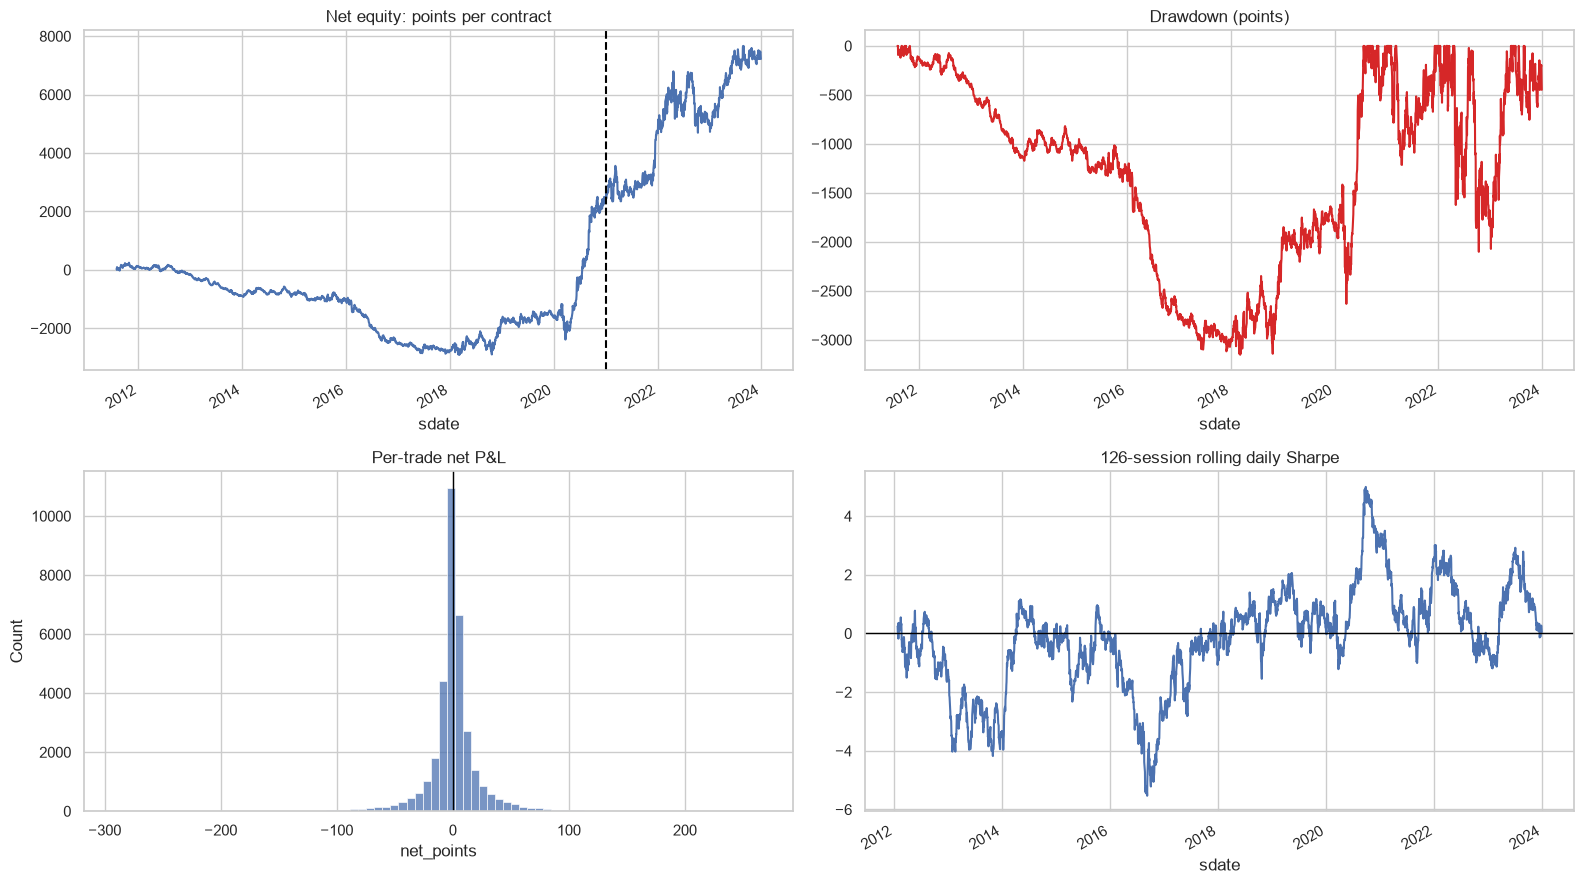

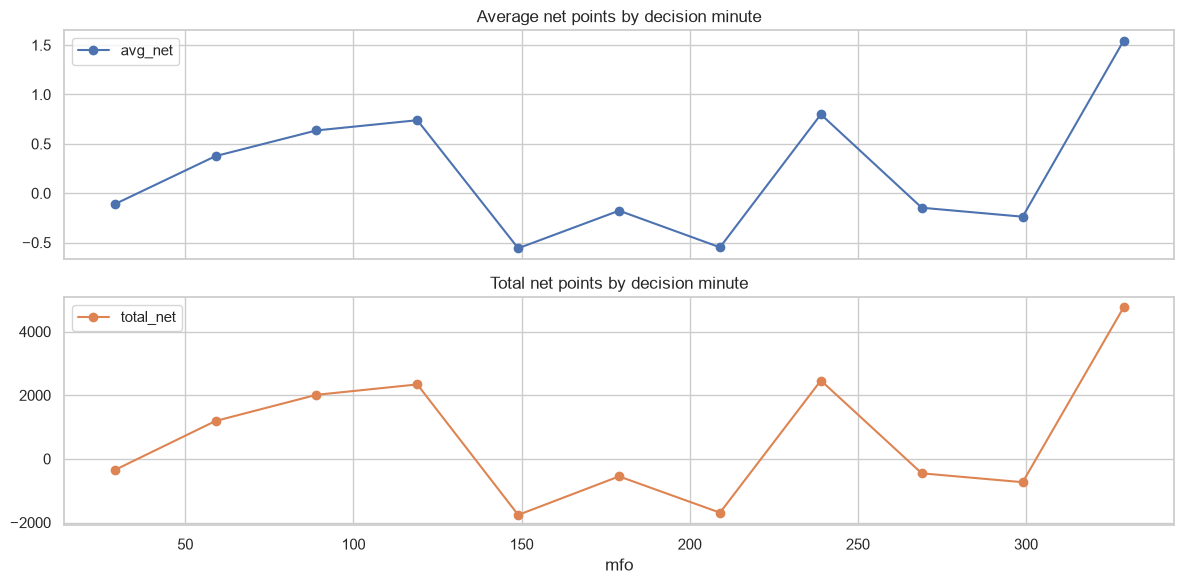

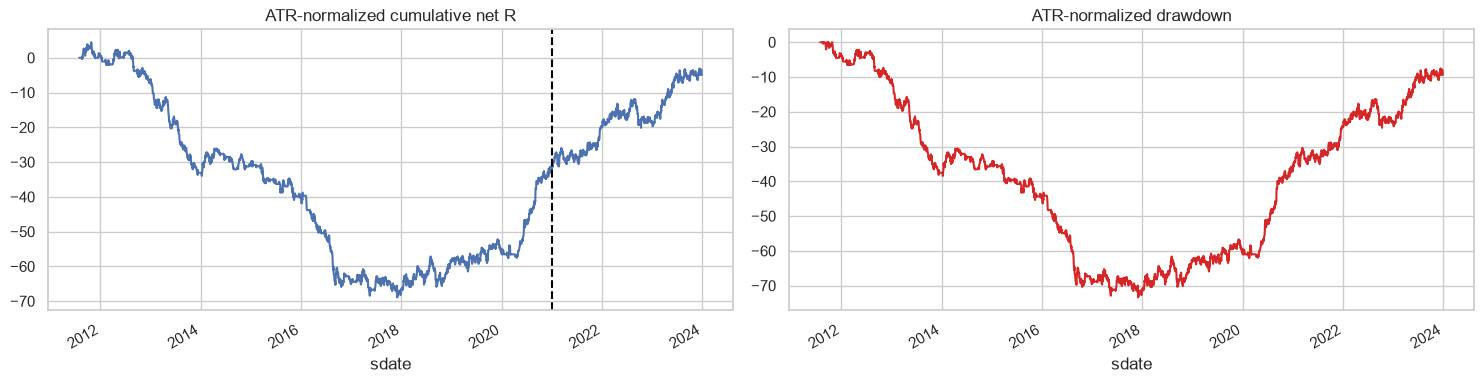

These controls compare signal pairing on attainable fixed-horizon fills; they do not substitute for fill validation or a full claim-matched null.


In [14]:
all_dates = d['sdate'].drop_duplicates().sort_values()
daily_pnl = trades.groupby('sdate')['net_points'].sum().reindex(all_dates, fill_value=0.0)
equity = daily_pnl.cumsum()
drawdown = equity - equity.cummax()
rolling_sharpe = np.sqrt(252) * daily_pnl.rolling(126).mean() / daily_pnl.rolling(126).std()

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
equity.plot(ax=axes[0,0], title='Net equity: points per contract'); axes[0,0].axvline(EVAL_START, color='black', ls='--')
drawdown.plot(ax=axes[0,1], color='tab:red', title='Drawdown (points)')
sns.histplot(trades.net_points, bins=80, ax=axes[1,0]); axes[1,0].axvline(0,color='black',lw=1); axes[1,0].set_title('Per-trade net P&L')
rolling_sharpe.plot(ax=axes[1,1], title='126-session rolling daily Sharpe'); axes[1,1].axhline(0,color='black',lw=1)
plt.tight_layout(); plt.show()

regime_strategy = trades.groupby(['daily_vol_regime','daily_market_regime'], observed=True).agg(
    trades=('net_points','size'), avg_net_points=('net_points','mean'), win_rate=('net_points',lambda s:(s>0).mean()), net_points=('net_points','sum'))
display(regime_strategy.style.format({'avg_net_points':'{:+.3f}','win_rate':'{:.1%}','net_points':'{:+.1f}'}))

slot_strategy = trades.groupby('mfo').agg(trades=('net_points','size'), avg_net=('net_points','mean'), total_net=('net_points','sum'))
slot_strategy[['avg_net','total_net']].plot(subplots=True, marker='o', figsize=(12,6), title=['Average net points by decision minute','Total net points by decision minute']); plt.tight_layout(); plt.show()

daily_r = trades.dropna(subset=['net_r']).groupby('sdate')['net_r'].sum().reindex(all_dates, fill_value=0.0)
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
daily_r.cumsum().plot(ax=ax[0], title='ATR-normalized cumulative net R'); ax[0].axvline(EVAL_START, color='black', ls='--')
(daily_r.cumsum() - daily_r.cumsum().cummax()).plot(ax=ax[1], color='tab:red', title='ATR-normalized drawdown')
plt.tight_layout(); plt.show()

# Cost stress reruns accounting from gross fills; it does not validate those fills.
cost_grid = sorted(set([0.0, ROUND_TRIP_COST_POINTS, 0.35, 0.50, 0.75, 1.00]))
cost_rows = []
for era in [f'train_through_{TRAIN_END.year}', EVAL_LABEL]:
    dates_era = d.loc[d.era.eq(era), 'sdate'].drop_duplicates()
    for cost in cost_grid:
        tc = trades.loc[trades.era.eq(era)].copy()
        tc['cost_points'] = cost; tc['net_points'] = tc['gross_points'] - cost
        tc['net_dollars'] = tc['net_points'] * POINT_VALUE
        tc['cost_r'] = cost / tc['daily_atr_14']; tc['net_r'] = tc['gross_r'] - tc['cost_r']
        sc = strategy_statistics(tc, dates_era)
        cost_rows.append({'era':era,'round_trip_cost_points':cost,'avg_net_points':sc.mean_net_points_trade,
                          'sharpe_points':sc.daily_sharpe_points,'sharpe_r':sc.daily_sharpe_r,'net_r':sc.net_r})
cost_stress = pd.DataFrame(cost_rows)
display(cost_stress.pivot(index='round_trip_cost_points', columns='era', values=['avg_net_points','sharpe_points','sharpe_r']).style.format('{:+.3f}'))

# Same-clock signal controls on one common sample.
control_base = trades.dropna(subset=['ret_30m','daily_atr_14']).copy()
control_sides = {'vwap_side':control_base.vwap_side, 'always_long':1, 'always_short':-1,
                 'past_30m_momentum':np.sign(control_base.ret_30m)}
control_rows = []
for era in [f'train_through_{TRAIN_END.year}', EVAL_LABEL]:
    dates_era = d.loc[d.era.eq(era), 'sdate'].drop_duplicates()
    for name, side_values in control_sides.items():
        tc = control_base.loc[control_base.era.eq(era)].copy()
        tc['test_side'] = side_values.loc[tc.index] if isinstance(side_values, pd.Series) else side_values
        tc = tc.loc[tc.test_side.ne(0)].copy()
        tc['gross_points'] = tc.test_side * (tc.exit_open - tc.entry_open)
        tc['net_points'] = tc.gross_points - ROUND_TRIP_COST_POINTS; tc['net_dollars'] = tc.net_points * POINT_VALUE
        tc['gross_r'] = tc.gross_points / tc.daily_atr_14; tc['cost_r'] = ROUND_TRIP_COST_POINTS / tc.daily_atr_14; tc['net_r'] = tc.gross_r - tc.cost_r
        sc = strategy_statistics(tc, dates_era)
        control_rows.append({'era':era,'signal':name,'trades':sc.trades,'gross_per_trade':tc.gross_points.mean(),
                             'net_per_trade':sc.mean_net_points_trade,'sharpe_r':sc.daily_sharpe_r,'daily_t_r':sc.daily_t_r})
signal_controls = pd.DataFrame(control_rows)
display(signal_controls.set_index(['era','signal']).style.format('{:+.4f}'))
print('These controls compare signal pairing on attainable fixed-horizon fills; they do not substitute for fill validation or a full claim-matched null.')


## 7. Machine-learning dataset and chronological split

Regression predicts the 30-minute entry-to-exit return in basis points. Classification predicts whether that return is positive. Preprocessing is fit only on the training era. No random train/test split is used. Models are compared with naive baselines.


In [15]:
model_columns = feature_columns_numeric + feature_columns_categorical
model_data = d.loc[d.target_ret_bp.notna(), ['sdate','mfo','target_ret_bp','target_up'] + model_columns].copy()
train = model_data.loc[model_data.sdate <= TRAIN_END].copy()
evaluation = model_data.loc[(model_data.sdate >= EVAL_START) & (model_data.sdate <= EVAL_END)].copy()
assert train.sdate.max() <= TRAIN_END and evaluation.sdate.min() >= EVAL_START and evaluation.sdate.max() < pd.Timestamp('2024-01-01')

X_train, y_train_reg, y_train_cls = train[model_columns], train['target_ret_bp'], train['target_up'].astype(int)
X_eval, y_eval_reg, y_eval_cls = evaluation[model_columns], evaluation['target_ret_bp'], evaluation['target_up'].astype(int)

numeric_transformer = Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True)), ('scale', StandardScaler())])
categorical_transformer = Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocess = ColumnTransformer([('num', numeric_transformer, feature_columns_numeric), ('cat', categorical_transformer, feature_columns_categorical)])

print(f'Train: {len(train):,} rows, {train.sdate.min().date()} to {train.sdate.max().date()}')
print(f'Evaluation: {len(evaluation):,} rows, {evaluation.sdate.min().date()} to {evaluation.sdate.max().date()}')
print(f'Train positive rate: {y_train_cls.mean():.2%}; evaluation positive rate: {y_eval_cls.mean():.2%}')


Train: 26,056 rows, 2011-08-01 to 2020-12-31
Evaluation: 8,363 rows, 2021-01-04 to 2023-12-29
Train positive rate: 51.78%; evaluation positive rate: 52.82%


## 8. Regression and classification models

The linear models provide an interpretable baseline. Histogram gradient boosting supplies a nonlinear tree benchmark available in scikit-learn. If `xgboost` is installed, matched XGBoost regression and classification models are added automatically. Hyperparameters are intentionally modest and are not tuned on 2022–2023.


In [16]:
regression_models = {
    'mean_baseline': Pipeline([('prep', preprocess), ('model', DummyRegressor(strategy='mean'))]),
    'linear_regression': Pipeline([('prep', preprocess), ('model', LinearRegression())]),
    'hist_gradient_boosting': Pipeline([('prep', preprocess), ('model', HistGradientBoostingRegressor(
        max_iter=250, learning_rate=.04, max_leaf_nodes=15, l2_regularization=1.0, random_state=RANDOM_SEED))])
}
if XGBOOST_AVAILABLE:
    regression_models['xgboost'] = Pipeline([('prep', preprocess), ('model', XGBRegressor(
        n_estimators=400, learning_rate=.03, max_depth=3, min_child_weight=5, subsample=.8, colsample_bytree=.8,
        reg_lambda=5.0, objective='reg:squarederror', n_jobs=-1, random_state=RANDOM_SEED))])

regression_predictions = {}
regression_rows = []
for name, model in regression_models.items():
    model.fit(X_train, y_train_reg)
    pred = model.predict(X_eval)
    regression_predictions[name] = pred
    regression_rows.append({
        'model':name, 'mae_bp':mean_absolute_error(y_eval_reg,pred),
        'rmse_bp':np.sqrt(mean_squared_error(y_eval_reg,pred)), 'r2':r2_score(y_eval_reg,pred),
        'pearson_ic':pearsonr(pred,y_eval_reg).statistic if np.std(pred)>0 else np.nan,
        'spearman_ic':spearmanr(pred,y_eval_reg).statistic if np.std(pred)>0 else np.nan,
        'direction_accuracy':accuracy_score(y_eval_cls,pred>0)
    })
regression_results = pd.DataFrame(regression_rows).set_index('model')
display(regression_results.style.format({'mae_bp':'{:.3f}','rmse_bp':'{:.3f}','r2':'{:+.4f}','pearson_ic':'{:+.4f}','spearman_ic':'{:+.4f}','direction_accuracy':'{:.1%}'}))


C:\Users\VuDoa\AppData\Local\Temp\ipykernel_9660\2752792192.py:21: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'pearson_ic':pearsonr(pred,y_eval_reg).statistic if np.std(pred)>0 else np.nan,
C:\Users\VuDoa\AppData\Local\Temp\ipykernel_9660\2752792192.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'spearman_ic':spearmanr(pred,y_eval_reg).statistic if np.std(pred)>0 else np.nan,


,mae_bp,rmse_bp,r2,pearson_ic,spearman_ic,direction_accuracy
model,,,,,,
mean_baseline,20.933,30.178,-0.0000,+nan,+nan,52.8%
linear_regression,20.975,30.222,-0.0029,+0.0069,+0.0186,49.8%
hist_gradient_boosting,20.957,30.211,-0.0022,+0.0218,+0.0081,52.2%
xgboost,21.091,30.441,-0.0175,+0.0141,+0.0200,51.6%


In [17]:
classification_models = {
    'prior_baseline': Pipeline([('prep', preprocess), ('model', DummyClassifier(strategy='prior'))]),
    'logistic_regression': Pipeline([('prep', preprocess), ('model', LogisticRegression(C=.25, max_iter=2000, random_state=RANDOM_SEED))]),
    'hist_gradient_boosting': Pipeline([('prep', preprocess), ('model', HistGradientBoostingClassifier(
        max_iter=250, learning_rate=.04, max_leaf_nodes=15, l2_regularization=1.0, random_state=RANDOM_SEED))])
}
if XGBOOST_AVAILABLE:
    classification_models['xgboost'] = Pipeline([('prep', preprocess), ('model', XGBClassifier(
        n_estimators=400, learning_rate=.03, max_depth=4, min_child_weight=20, subsample=.8, colsample_bytree=.8,
        reg_lambda=5.0, eval_metric='logloss', n_jobs=-1, random_state=RANDOM_SEED))])

classification_probabilities = {}
classification_rows = []
for name, model in classification_models.items():
    model.fit(X_train, y_train_cls)
    prob = model.predict_proba(X_eval)[:,1]
    classification_probabilities[name] = prob
    classification_rows.append({
        'model':name, 'roc_auc':roc_auc_score(y_eval_cls,prob), 'log_loss':log_loss(y_eval_cls,prob),
        'brier':brier_score_loss(y_eval_cls,prob), 'accuracy_50pct':accuracy_score(y_eval_cls,prob>=.5),
        'probability_spearman_ic':spearmanr(prob,y_eval_reg).statistic if np.std(prob)>0 else np.nan
    })
classification_results = pd.DataFrame(classification_rows).set_index('model')
display(classification_results.style.format({'roc_auc':'{:.4f}','log_loss':'{:.4f}','brier':'{:.4f}','accuracy_50pct':'{:.1%}','probability_spearman_ic':'{:+.4f}'}))


C:\Users\VuDoa\AppData\Local\Temp\ipykernel_9660\3832468704.py:21: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'probability_spearman_ic':spearmanr(prob,y_eval_reg).statistic if np.std(prob)>0 else np.nan


,roc_auc,log_loss,brier,accuracy_50pct,probability_spearman_ic
model,,,,,
prior_baseline,0.5000,0.6918,0.2493,52.8%,+nan
logistic_regression,0.5002,0.6934,0.2501,51.4%,+0.0152
hist_gradient_boosting,0.4977,0.6921,0.2495,52.9%,-0.0063
xgboost,0.5102,0.6941,0.2505,52.0%,+0.0129


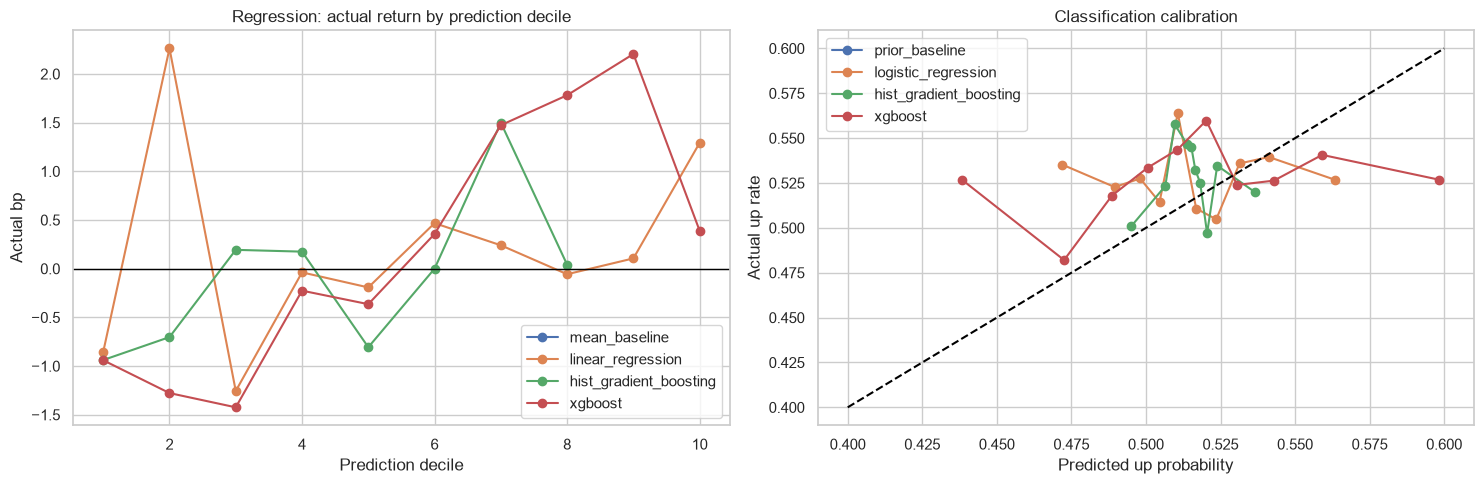

,coefficient
num__missingindicator_close_vs_prior_low_60m_atr,-5.8757
num__missingindicator_close_vs_prior_high_60m_atr,-5.8757
num__missingindicator_volume_vs_prev_30m,-5.1718
num__missingindicator_rv_30m,-5.1718
num__missingindicator_ret_30m,-5.1718
num__rv_30m,-1.6745
num__missingindicator_vei_pct,-1.4454
num__missingindicator_vei_z_90,-1.4454
num__donchian_pos_15m,-1.1302
num__ema_spread_atr,-1.0961


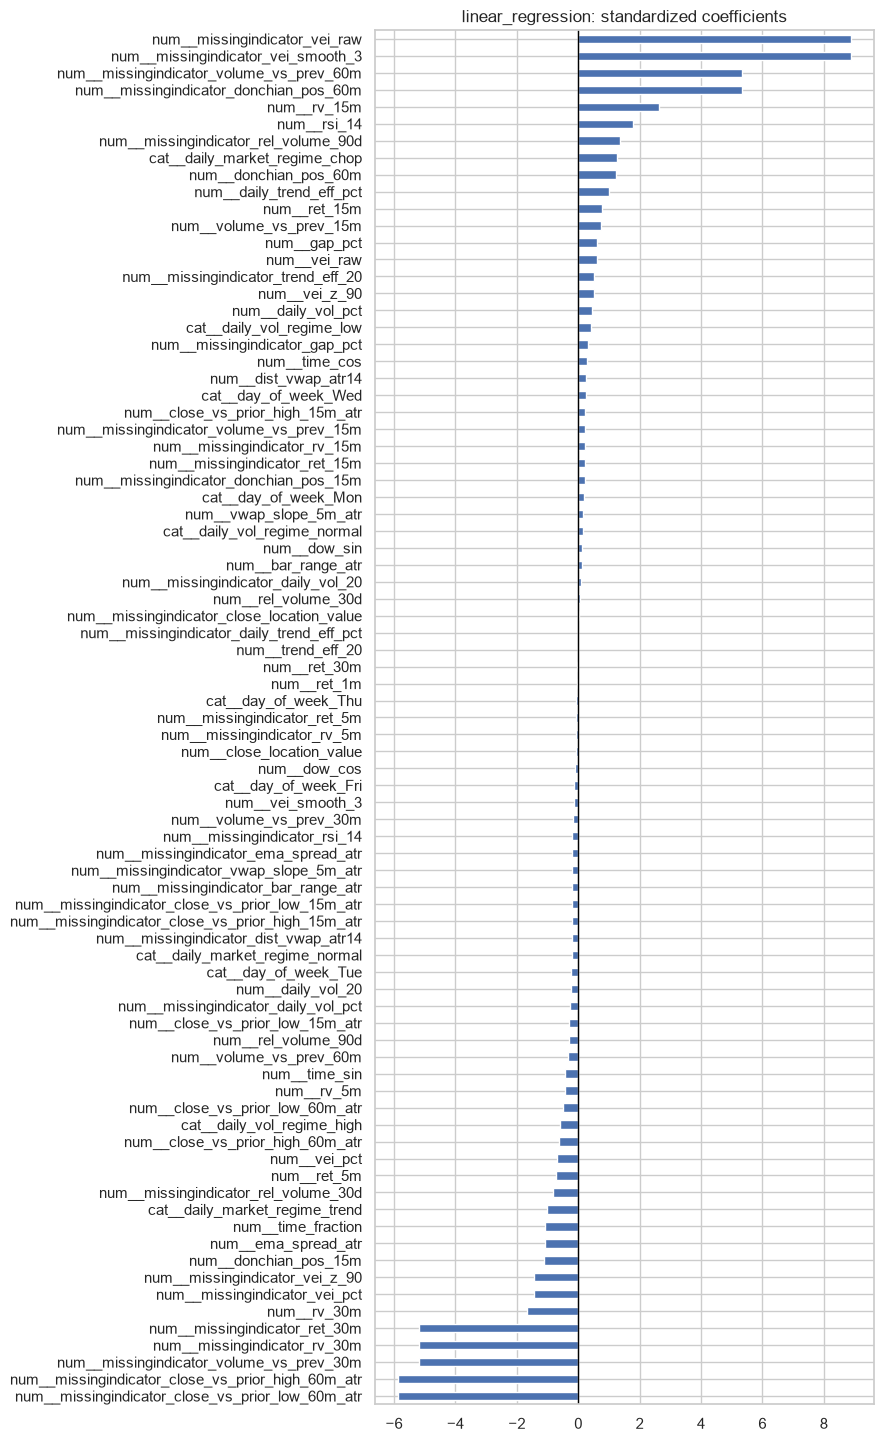

,coefficient
num__donchian_pos_15m,-0.0991
num__time_fraction,-0.0991
num__close_vs_prior_high_60m_atr,-0.0806
num__ema_spread_atr,-0.0779
num__missingindicator_vei_z_90,-0.0712
num__missingindicator_vei_pct,-0.0712
cat__daily_market_regime_trend,-0.0488
num__missingindicator_rel_volume_30d,-0.0471
num__close_vs_prior_low_60m_atr,-0.0423
num__time_sin,-0.0394


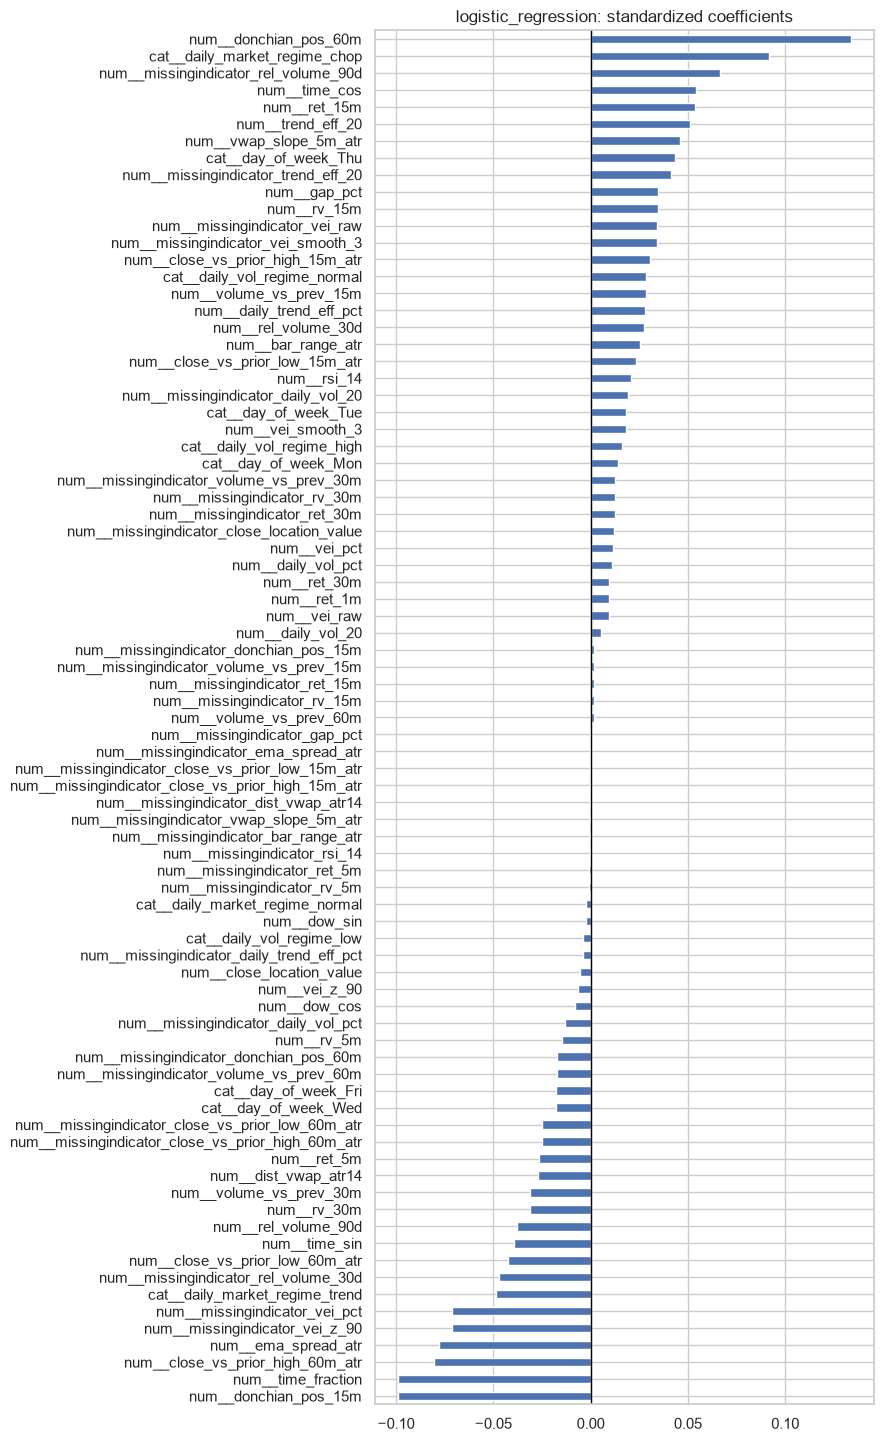

In [18]:
# Economic calibration: realized returns by prediction decile.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, pred in regression_predictions.items():
    if np.std(pred) == 0:
        continue
    temp = pd.DataFrame({'pred':pred,'actual':y_eval_reg.to_numpy()})
    temp['decile'] = pd.qcut(temp.pred, 10, labels=False, duplicates='drop')
    calibration = temp.groupby('decile').agg(predicted=('pred','mean'), actual=('actual','mean'))
    axes[0].plot(calibration.index + 1, calibration.actual, marker='o', label=name)
for name, prob in classification_probabilities.items():
    if np.std(prob) == 0:
        continue
    temp = pd.DataFrame({'prob':prob,'up':y_eval_cls.to_numpy()})
    temp['decile'] = pd.qcut(temp.prob, 10, labels=False, duplicates='drop')
    calibration = temp.groupby('decile').agg(predicted=('prob','mean'), actual=('up','mean'))
    axes[1].plot(calibration.predicted, calibration.actual, marker='o', label=name)
axes[0].axhline(0,color='black',lw=1); axes[0].set(title='Regression: actual return by prediction decile',xlabel='Prediction decile',ylabel='Actual bp'); axes[0].legend()
axes[1].plot([.4,.6],[.4,.6],color='black',ls='--'); axes[1].set(title='Classification calibration',xlabel='Predicted up probability',ylabel='Actual up rate'); axes[1].legend()
plt.tight_layout(); plt.show()

# Coefficients from the linear and logistic models.
for name, fitted in [('linear_regression',regression_models['linear_regression']), ('logistic_regression',classification_models['logistic_regression'])]:
    names = fitted.named_steps['prep'].get_feature_names_out()
    coef = fitted.named_steps['model'].coef_.reshape(-1)
    coef_table = pd.Series(coef,index=names,name='coefficient').sort_values()
    display(coef_table.to_frame().style.format('{:+.4f}'))
    coef_table.plot.barh(figsize=(9,max(6,len(coef_table)*.18)),title=f'{name}: standardized coefficients'); plt.axvline(0,color='black',lw=1); plt.tight_layout(); plt.show()


In [ ]:
# Permutation importance uses a fixed evaluation subsample and reports loss of model score when each raw feature is shuffled.
if RUN_PERMUTATION_IMPORTANCE:
    rng = np.random.default_rng(RANDOM_SEED)
    sample_n = min(5000, len(X_eval))
    sample_idx = rng.choice(len(X_eval), sample_n, replace=False)
    candidate_name = 'xgboost' if XGBOOST_AVAILABLE else 'hist_gradient_boosting'
    fitted = regression_models[candidate_name]
    pi = permutation_importance(fitted, X_eval.iloc[sample_idx], y_eval_reg.iloc[sample_idx],
                                scoring='neg_mean_squared_error', n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1)
    importance = pd.Series(pi.importances_mean, index=model_columns).sort_values()
    display(importance.sort_values(ascending=False).to_frame('permutation_importance').head(25).style.format('{:.4g}'))
    importance.tail(25).plot.barh(figsize=(9,7),title=f'{candidate_name}: top permutation importance'); plt.tight_layout(); plt.show()


## 9. Walk-forward magnitude forecasting and VEI ablation

The signed-return models above are retained as a documented no-go screen. This section tests the stronger descriptive result: forecasting the **size** of the next 30-minute move. Each test year is predicted using only earlier years. Every learned model uses the same histogram-gradient-boosting specification so changes can be attributed to feature sets rather than to model selection.

Two targets are evaluated: raw absolute basis points and absolute basis points divided by the causal trailing same-slot median. The model ladder asks whether volume and then VEI add information beyond recent realized volatility, daily volatility, and time of day. These are walk-forward exploratory estimates on consumed history, not a clean holdout.


In [19]:
magnitude_feature_sets = {
    'slot_baseline': [],
    'vol_core': ['slot_absret_median_90','time_sin','time_cos','rv_5m','rv_15m','rv_30m','daily_vol_20','daily_vol_pct'],
    'vol_plus_volume': ['slot_absret_median_90','time_sin','time_cos','rv_5m','rv_15m','rv_30m','daily_vol_20','daily_vol_pct',
                        'rel_volume_30d','rel_volume_90d','volume_vs_prev_15m','volume_vs_prev_30m','volume_vs_prev_60m'],
}
magnitude_feature_sets['vol_volume_vei_raw'] = magnitude_feature_sets['vol_plus_volume'] + ['vei_raw']
magnitude_feature_sets['vol_volume_vei_z'] = magnitude_feature_sets['vol_plus_volume'] + ['vei_z_90']
magnitude_feature_sets['vol_volume_vei_pct_z'] = magnitude_feature_sets['vol_plus_volume'] + ['vei_pct','vei_z_90']
display(pd.DataFrame({'model':magnitude_feature_sets.keys(), 'features':[', '.join(v) if v else 'causal same-slot median' for v in magnitude_feature_sets.values()]}))

magnitude_data = d.loc[d.target_ret_bp.notna() & d.slot_absret_median_90.notna()].copy()
magnitude_data['target_abs_bp'] = magnitude_data['abs_target_bp']
magnitude_data['target_normalized_abs'] = magnitude_data['normalized_abs_target']
magnitude_targets = {'absolute_bp':'target_abs_bp', 'normalized_absolute':'target_normalized_abs'}
walkforward_years = [y for y in sorted(magnitude_data.sdate.dt.year.unique()) if MAGNITUDE_FIRST_TEST_YEAR <= y <= EVAL_END.year]

def magnitude_model_pipeline(seed):
    return Pipeline([
        ('impute', SimpleImputer(strategy='median', add_indicator=True)),
        ('model', HistGradientBoostingRegressor(max_iter=250, learning_rate=.04, max_leaf_nodes=15,
                                                l2_regularization=1.0, random_state=seed))
    ])

walkforward_rows = []
if RUN_MAGNITUDE_WALK_FORWARD:
    for target_name, target_col in magnitude_targets.items():
        for year in walkforward_years:
            wf_train = magnitude_data.loc[magnitude_data.sdate.dt.year < year].dropna(subset=[target_col]).copy()
            wf_test = magnitude_data.loc[magnitude_data.sdate.dt.year == year].dropna(subset=[target_col]).copy()
            if len(wf_train) < 1000 or len(wf_test) < 100:
                continue
            baseline_pred = wf_test.slot_absret_median_90.to_numpy(float) if target_name == 'absolute_bp' else np.ones(len(wf_test))
            for j, row in enumerate(wf_test[['sdate','mfo']].itertuples(index=False)):
                walkforward_rows.append({'target_type':target_name,'model':'slot_baseline','year':year,'sdate':row.sdate,'mfo':row.mfo,
                                         'actual':wf_test[target_col].iloc[j], 'prediction':baseline_pred[j]})
            for model_name, cols in magnitude_feature_sets.items():
                if model_name == 'slot_baseline':
                    continue
                model = magnitude_model_pipeline(RANDOM_SEED + year)
                model.fit(wf_train[cols], np.log1p(wf_train[target_col].clip(lower=0)))
                pred = np.expm1(model.predict(wf_test[cols])).clip(min=0)
                for j, row in enumerate(wf_test[['sdate','mfo']].itertuples(index=False)):
                    walkforward_rows.append({'target_type':target_name,'model':model_name,'year':year,'sdate':row.sdate,'mfo':row.mfo,
                                             'actual':wf_test[target_col].iloc[j], 'prediction':pred[j]})
walkforward_predictions = pd.DataFrame(walkforward_rows)
print(f'Walk-forward predictions: {len(walkforward_predictions):,} rows across {len(walkforward_years)} test years')


,model,features
0,slot_baseline,causal same-slot median
1,vol_core,"slot_absret_median_90, time_sin, time_cos, rv_..."
2,vol_plus_volume,"slot_absret_median_90, time_sin, time_cos, rv_..."
3,vol_volume_vei_raw,"slot_absret_median_90, time_sin, time_cos, rv_..."
4,vol_volume_vei_z,"slot_absret_median_90, time_sin, time_cos, rv_..."
5,vol_volume_vei_pct_z,"slot_absret_median_90, time_sin, time_cos, rv_..."


Walk-forward predictions: 267,288 rows across 8 test years


In [20]:
def magnitude_score(frame):
    q = frame.dropna(subset=['actual','prediction']).copy()
    q['prediction_rank_in_year'] = (q.groupby('year')['prediction'].rank(pct=True, method='average')
                                    if 'year' in q.columns else q['prediction'].rank(pct=True, method='average'))
    low = q.loc[q.prediction_rank_in_year <= .20, 'actual'].mean()
    high = q.loc[q.prediction_rank_in_year > .80, 'actual'].mean()
    return pd.Series({'n':len(q), 'spearman_ic':spearmanr(q.prediction, q.actual).statistic,
                      'mae':mean_absolute_error(q.actual, q.prediction),
                      'bottom_quintile_actual':low, 'top_quintile_actual':high, 'top_minus_bottom':high-low})

magnitude_summary_rows = []
magnitude_boot_rng = np.random.default_rng(RANDOM_SEED + 17)
for (target_type, model_name), g in walkforward_predictions.groupby(['target_type','model']):
    sc = magnitude_score(g)
    ci_frame = g.rename(columns={'prediction':'pred_for_ci','actual':'actual_for_ci'})
    ic, lo, hi = fixed_rank_session_block_ic(ci_frame, 'pred_for_ci', 'actual_for_ci', IC_BOOT_DRAWS, magnitude_boot_rng)
    sc['target_type'] = target_type; sc['model'] = model_name; sc['ic_ci_lo'] = lo; sc['ic_ci_hi'] = hi
    magnitude_summary_rows.append(sc)
magnitude_summary = pd.DataFrame(magnitude_summary_rows).set_index(['target_type','model']).sort_index()
display(magnitude_summary.style.format({'spearman_ic':'{:+.4f}','ic_ci_lo':'{:+.4f}','ic_ci_hi':'{:+.4f}',
                                        'mae':'{:.4f}','bottom_quintile_actual':'{:.4f}','top_quintile_actual':'{:.4f}','top_minus_bottom':'{:+.4f}'}))

yearly_magnitude = walkforward_predictions.groupby(['target_type','model','year']).apply(magnitude_score, include_groups=False).reset_index()
display(yearly_magnitude.pivot_table(index=['target_type','year'], columns='model', values='spearman_ic').style.format('{:+.4f}'))

incremental = yearly_magnitude.pivot_table(index=['target_type','year'], columns='model', values='spearman_ic')
for candidate in ['vol_volume_vei_raw','vol_volume_vei_z','vol_volume_vei_pct_z']:
    incremental[f'{candidate}_delta_vs_vol_volume'] = incremental[candidate] - incremental['vol_plus_volume']
delta_cols = [c for c in incremental.columns if c.endswith('_delta_vs_vol_volume')]
display(incremental[delta_cols].style.format('{:+.4f}'))
print('Primary question: do VEI deltas remain positive across years and improve the session-block IC interval versus vol_plus_volume?')


C:\Users\VuDoa\AppData\Local\Temp\ipykernel_9660\3643287397.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pd.Series({'n':len(q), 'spearman_ic':spearmanr(q.prediction, q.actual).statistic,


C:\Users\VuDoa\AppData\Local\Temp\ipykernel_9660\3643287397.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pd.Series({'n':len(q), 'spearman_ic':spearmanr(q.prediction, q.actual).statistic,
C:\Users\VuDoa\AppData\Local\Temp\ipykernel_9660\3643287397.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pd.Series({'n':len(q), 'spearman_ic':spearmanr(q.prediction, q.actual).statistic,
C:\Users\VuDoa\AppData\Local\Temp\ipykernel_9660\3643287397.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pd.Series({'n':len(q), 'spearman_ic':spearmanr(q.prediction, q.actual).statistic,
C:\Users\VuDoa\AppData\Local\Temp\ipykernel_9660\3643287397.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pd.Series({'n':len(q), 'spearman_ic':spearmanr(q.prediction, q.actual).statist

Primary question: do VEI deltas remain positive across years and improve the session-block IC interval versus vol_plus_volume?


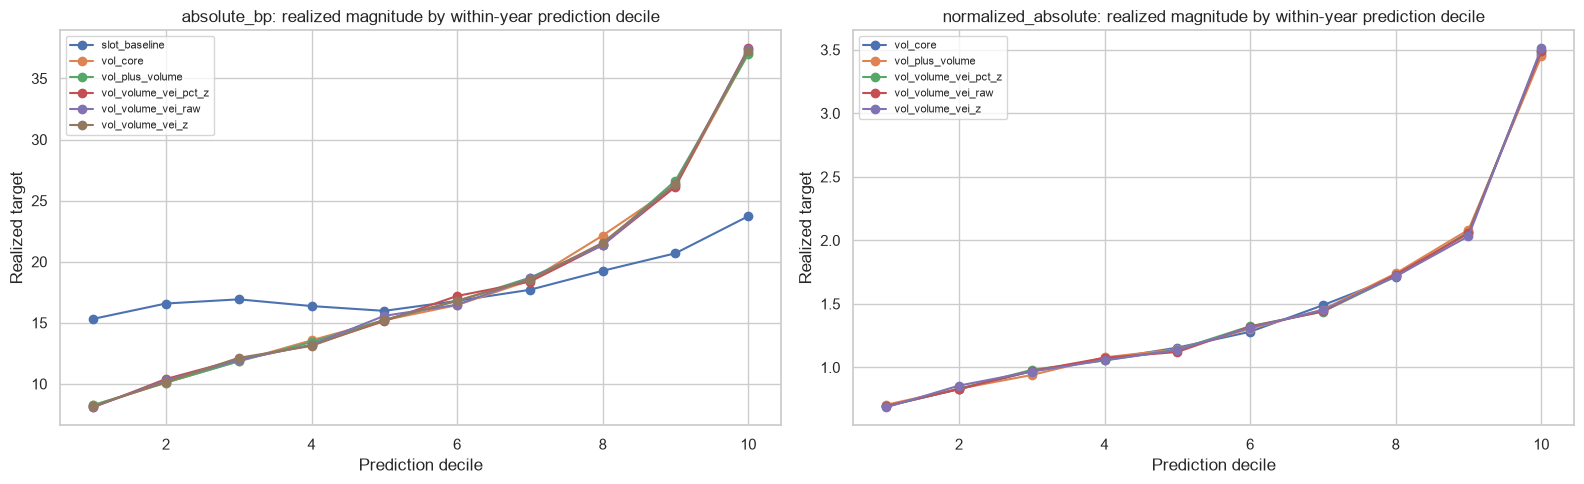

Suggested exploratory kill rule: reject incremental VEI magnitude value if its mean IC delta is <=0, if it is positive in fewer than 60% of walk-forward years, or if ES does not reproduce the sign.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, target_type in zip(axes, magnitude_targets):
    subset = walkforward_predictions.loc[walkforward_predictions.target_type.eq(target_type)].copy()
    for model_name, g in subset.groupby('model'):
        if g.prediction.nunique() < 10:
            continue
        g['decile'] = g.groupby('year')['prediction'].transform(lambda s: pd.qcut(s.rank(method='first'), 10, labels=False, duplicates='drop'))
        calibration = g.groupby('decile').agg(predicted=('prediction','mean'), actual=('actual','mean'))
        ax.plot(calibration.index + 1, calibration.actual, marker='o', label=model_name)
    ax.set(title=f'{target_type}: realized magnitude by within-year prediction decile', xlabel='Prediction decile', ylabel='Realized target')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

vei_delta_summary = incremental[delta_cols].groupby(level='target_type').agg(['mean','median',lambda s:(s>0).mean()])
display(vei_delta_summary.style.format('{:+.4f}'))
print('Suggested exploratory kill rule: reject incremental VEI magnitude value if its mean IC delta is <=0, if it is positive in fewer than 60% of walk-forward years, or if ES does not reproduce the sign.')


### Cross-market replication

Change only `INSTRUMENT = 'ES'` in the configuration and rerun all cells. Do not change feature sets, model parameters, target, years, or the kill rule after seeing NQ. NQ and ES are highly dependent, so agreement is a robustness check rather than an independent holdout. Preserve both executed notebooks or export the two magnitude-summary tables before comparing them.


## 10. Research checklist and room to explore

Before interpreting a survivor:

- Confirm coverage loss by year and decision minute is not selecting favorable periods.
- Require sign and useful magnitude across years, not only pooled IC.
- Compare gross edge with costs; a gross effect approximately equal to modeled cost is cost-model-dependent.
- Treat every feature/model/threshold comparison above as multiple searching on consumed history.
- Do not open 2024+ in this notebook. The broader VEI project previously inspected later history, so 2024+ is operationally sealed here but is not a genuinely untouched project-level holdout.
- Only newly arriving future data can supply clean confirmation; freeze and record the complete pipeline before that shadow period.

Remaining useful work after this notebook: rerun unchanged on ES, independently review the causal masks and accounting, export a frozen model card, and test a surviving magnitude forecast only as a risk/sizing input to a separately validated strategy.


In [ ]:
# Exploration scratchpad — keep the OOS assertion in place.
assert bars.sdate.max() < pd.Timestamp('2024-01-01')

# Example: inspect a feature against the target by era.
FEATURE_TO_EXPLORE = 'vei_z_90'
explore = d[['sdate','era',FEATURE_TO_EXPLORE,'target_ret_bp']].dropna().copy()
explore['quintile'] = explore.groupby('era')[FEATURE_TO_EXPLORE].transform(lambda s: pd.qcut(s,5,labels=False,duplicates='drop'))
display(explore.groupby(['era','quintile']).agg(n=('target_ret_bp','size'), feature_mean=(FEATURE_TO_EXPLORE,'mean'), target_bp=('target_ret_bp','mean')))
